[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arvidl/BMED365-2026/blob/main/Lab1-NetworkSci-PSN/notebooks/02a-patient_similarity_network_iris_solutions.ipynb)


Version 2025-12-21, A. Lundervold

Use the `bmed365-2026` conda environment

# Solutions: Patient Similarity Network with IRIS Data

**This is the solutions notebook for `02-patient_similarity_network_iris.ipynb`.**

Here you will find complete solutions with explanations and commented code for all 10 exercises.


---
## Setup: Load data and build the basic network

First, we run the setup from the main notebook so that we have data and network available.


In [1]:
# ============================================================
# SETUP - Run this cell first!
# ============================================================

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
import community.community_louvain as community_louvain
from scipy.spatial.distance import cityblock
import random

# Load IRIS data
iris = load_iris()
X = iris.data
y = iris.target
species = iris.target_names

# Build basic network (as in the main notebook)
G = nx.Graph()
for i in range(len(X)):
    G.add_node(i, species=species[y[i]])

for i in range(len(X)):
    for j in range(i+1, len(X)):
        distance = np.linalg.norm(X[i] - X[j])
        similarity = 1 / (1.0 + distance)
        G.add_edge(i, j, weight=similarity)

# Compute layout (reused in multiple exercises)
pos = nx.spring_layout(G, k=1, seed=42)

# Run community detection on the basic network
communities_original = community_louvain.best_partition(G)

# Colors
species_colors = {'setosa': '#E63946', 'versicolor': '#FFD700', 'virginica': '#457B9D'}

print("✓ Setup complete!")
print(f"  • {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"  • {len(set(communities_original.values()))} communities detected")


✓ Setup complete!
  • 150 nodes, 11175 edges
  • 3 communities detected


---
## Exercise 1: Alternative Similarity Measure – Gaussian Kernel ⭐

### Motivation

In the main notebook, we used **normalized inverse Euclidean distance** as our similarity measure:

$$s_{ij} = \frac{1}{1 + d_{ij}}$$

But this is just **one of many possible ways** to transform distance to similarity. The choice of similarity measure can have a significant impact on:
- Which patients are considered "similar"
- Network structure (density, clusters)
- Community detection results

In this exercise, we explore the **Gaussian kernel** (RBF), an alternative similarity measure that is widely used in machine learning.

---

### How Do We Measure Success? Introducing ARI

To evaluate how well community detection finds the "correct" groupings, we need a **quantitative metric**. We use the **Adjusted Rand Index (ARI)**.

#### What is ARI?

ARI measures the **similarity between two groupings** (clusterings) – in our case:
1. **Actual groups**: The true species (setosa, versicolor, virginica)
2. **Detected groups**: Communities found by the Louvain algorithm

#### Mathematical Definition

Given two groupings $U$ and $V$ of $n$ elements, ARI is calculated from the **contingency table**:

$$\text{ARI} = \frac{\text{RI} - \mathbb{E}[\text{RI}]}{\max(\text{RI}) - \mathbb{E}[\text{RI}]}$$

where Rand Index (RI) counts the proportion of pairs that are either:
- **Together in both** groupings, or
- **Separated in both** groupings

#### Interpreting ARI

| ARI Value | Interpretation |
|-----------|----------------|
| **1.0** | Perfect match – identical groupings |
| **0.0** | Random – no better than guessing |
| **< 0** | Worse than random |
| **0.7-0.9** | Good to excellent match |
| **0.5-0.7** | Moderate match |

**Advantages of ARI:**
- Adjusted for random chance
- Symmetric – the order of groupings does not matter
- Values between -0.5 and 1.0 (typically 0-1)

---

### Task

Modify the code to use the **Gaussian kernel** (RBF) instead of our inverse distance:

$$s_{ij} = \exp\left(-\frac{d_{ij}^2}{2\sigma^2}\right)$$

**Subtasks:**
1. Implement this similarity formula
2. Experiment with different values of $\sigma$ (0.5, 1.0, 2.0, 5.0)
3. Use ARI to evaluate how well community detection recovers the actual species
4. How does $\sigma$ affect network structure and ARI?

---

### Solution

The **Gaussian kernel** (also called RBF - Radial Basis Function) is a popular similarity measure because:
- It gives values between 0 and 1
- Similarity decreases exponentially with distance
- $\sigma$ controls the "width" – how quickly similarity falls off

**Why experiment with $\sigma$?**
- **Small $\sigma$**: Only very close points have high similarity → many small, tight clusters
- **Large $\sigma$**: Even distant points have moderate similarity → one large, diffuse cluster
- **Optimal $\sigma$**: Balance that reflects the natural structure of the data


EXERCISE 1: Gaussian kernel with different sigma values

σ = 0.5:
  • Number of communities: 3
  • ARI (vs. actual species): 0.731
  • Average similarity: 0.117

σ = 1.0:
  • Number of communities: 3
  • ARI (vs. actual species): 0.730
  • Average similarity: 0.280

σ = 2.0:
  • Number of communities: 2
  • ARI (vs. actual species): 0.523
  • Average similarity: 0.509

σ = 5.0:
  • Number of communities: 2
  • ARI (vs. actual species): 0.507
  • Average similarity: 0.847


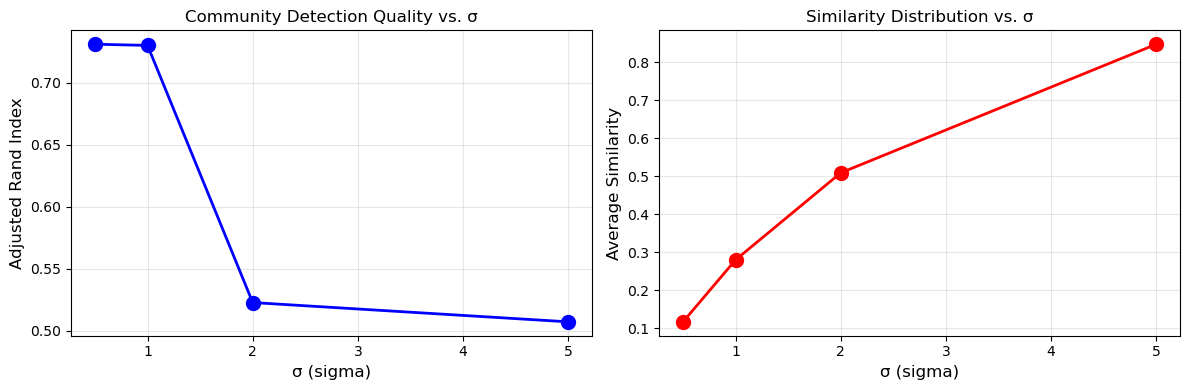


CONCLUSION:

• Small σ (0.5): Only very close nodes have high similarity. Can produce many small communities.
• Medium σ (1.0-2.0): Balanced - often gives best community detection.
• Large σ (5.0): All nodes get relatively similar similarity. Loses discriminating power.

For IRIS data, we see that σ ≈ 1-2 gives the best ARI, which corresponds to 
typical inter-point distance in the dataset.



In [2]:
# Exercise 1: Gaussian kernel with different sigma values

def build_gaussian_network(X, y, species, sigma):
    """
    Build network with Gaussian kernel as similarity measure.
    
    Formula: s_ij = exp(-d_ij^2 / (2 * sigma^2))
    """
    G_gauss = nx.Graph()
    
    # Add nodes
    for i in range(len(X)):
        G_gauss.add_node(i, species=species[y[i]])
    
    # Add edges with Gaussian similarity
    for i in range(len(X)):
        for j in range(i+1, len(X)):
            # Calculate Euclidean distance
            distance = np.linalg.norm(X[i] - X[j])
            
            # Gaussian kernel: exp(-d^2 / (2*sigma^2))
            similarity = np.exp(-(distance**2) / (2 * sigma**2))
            
            G_gauss.add_edge(i, j, weight=similarity)
    
    return G_gauss

# Test with different sigma values
sigmas = [0.5, 1.0, 2.0, 5.0]
results = []

print("="*60)
print("EXERCISE 1: Gaussian kernel with different sigma values")
print("="*60)

for sigma in sigmas:
    # Build network
    G_gauss = build_gaussian_network(X, y, species, sigma)
    
    # Community detection
    communities_gauss = community_louvain.best_partition(G_gauss)
    n_comm = len(set(communities_gauss.values()))
    
    # Calculate ARI against actual species
    ari = adjusted_rand_score(y, list(communities_gauss.values()))
    
    # Calculate average similarity
    avg_sim = np.mean([G_gauss[u][v]['weight'] for u, v in G_gauss.edges()])
    
    results.append({
        'sigma': sigma,
        'n_communities': n_comm,
        'ari': ari,
        'avg_similarity': avg_sim
    })
    
    print(f"\nσ = {sigma}:")
    print(f"  • Number of communities: {n_comm}")
    print(f"  • ARI (vs. actual species): {ari:.3f}")
    print(f"  • Average similarity: {avg_sim:.3f}")

# Visualize results
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot ARI vs sigma
ax1 = axes[0]
ax1.plot([r['sigma'] for r in results], [r['ari'] for r in results], 'bo-', linewidth=2, markersize=10)
ax1.set_xlabel('σ (sigma)', fontsize=12)
ax1.set_ylabel('Adjusted Rand Index', fontsize=12)
ax1.set_title('Community Detection Quality vs. σ', fontsize=12)
ax1.grid(True, alpha=0.3)

# Plot avg similarity vs sigma
ax2 = axes[1]
ax2.plot([r['sigma'] for r in results], [r['avg_similarity'] for r in results], 'ro-', linewidth=2, markersize=10)
ax2.set_xlabel('σ (sigma)', fontsize=12)
ax2.set_ylabel('Average Similarity', fontsize=12)
ax2.set_title('Similarity Distribution vs. σ', fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("CONCLUSION:")
print("="*60)
print("""
• Small σ (0.5): Only very close nodes have high similarity. Can produce many small communities.
• Medium σ (1.0-2.0): Balanced - often gives best community detection.
• Large σ (5.0): All nodes get relatively similar similarity. Loses discriminating power.

For IRIS data, we see that σ ≈ 1-2 gives the best ARI, which corresponds to 
typical inter-point distance in the dataset.
""")


---
## Exercise 2: Threshold-based Sparse Network ⭐

### Motivation: The Problem with Complete Networks

In the main notebook, we built a **complete network** where *all* pairs of flowers are connected by an edge. With 150 flowers, this gives:

$$\text{Number of edges} = \binom{150}{2} = \frac{150 \times 149}{2} = 11{,}175 \text{ edges}$$

**Problems with complete networks:**

| Problem | Consequence |
|---------|-------------|
| **Computation time** | $O(n^2)$ edges – scales poorly to large datasets |
| **Visualization** | Impossible to see structure when everything is connected |
| **Noise** | Weak connections (low similarity) "drown out" the important ones |
| **Memory** | Storage of millions of edges for large PSN |

**Clinical example:** A PSN with 10,000 patients would have ~50 million edges – impractical!

---

### What is a Sparse Network?

A **sparse network** is a network where most possible edges **do not exist**. We keep only the "most important" connections.

#### Mathematical Definition

**Network density** measures how "filled" a network is:

$$\text{Density} = \frac{\text{Actual edges}}{\text{Maximum possible edges}} = \frac{|E|}{\binom{n}{2}}$$

| Density | Network Type | Example |
|---------|--------------|---------|
| 1.0 | Complete | All pairs connected |
| 0.1-0.5 | Moderate | Typical social network |
| < 0.01 | Sparse | Typical biological network |
| → 0 | Very sparse | Large real-world networks |

**Important insight:** Most real networks (social, biological, technological) are naturally sparse!

---

### What is a Threshold?

A **threshold** $\tau$ is a cutoff value that determines which edges we keep:

$$\text{Edge }(i,j) \text{ is included} \iff s_{ij} \geq \tau$$

where $s_{ij}$ is the similarity between node $i$ and $j$.

#### How to Choose a Threshold?

| Strategy | Description | Advantage | Disadvantage |
|----------|-------------|-----------|--------------|
| **Fixed threshold** | E.g., $\tau = 0.5$ | Simple | Arbitrary choice |
| **Percentile** | Keep top 10% of edges | Controllable density | May lose important info |
| **k-nearest** | Keep k nearest neighbors per node | Guarantees connections | Asymmetric |
| **Adaptive** | Based on data distribution | Data-driven | More complex |

**Trade-off in threshold selection:**

```
Low threshold (τ → 0)          High threshold (τ → 1)
       ↓                            ↓
  Many edges                    Few edges
  Much noise                    Little noise
  Dense network                 Sparse network
  Unclear clusters              Clear clusters (or fragmented)
```

---

### Task

Build **sparse networks** with different thresholds and investigate how this affects:
1. Network density
2. Number of edges
3. Community detection (ARI)
4. Visualization

**Subtasks:**
1. Build networks with threshold = 0.3, 0.5, 0.7
2. Calculate network density for each threshold
3. Run community detection – do results change?
4. Find the "best" threshold for this dataset

---

### Solution

We implement a function that builds sparse networks by only including edges above a given threshold.

**Advantages of sparse networks:**
- **Faster computations** – fewer edges to process
- **Clearer structure** – noise is filtered out
- **Better visualization** – easier to see patterns and clusters
- **Scalability** – enables analysis of large datasets


EXERCISE 2: Threshold-based sparse networks

Threshold = 0.3:
  • Edges: 5,553 (49.7% of complete)
  • Network density: 0.4969
  • Communities: 2
  • ARI: 0.540

Threshold = 0.5:
  • Edges: 2,637 (23.6% of complete)
  • Network density: 0.2360
  • Communities: 3
  • ARI: 0.759

Threshold = 0.7:
  • Edges: 520 (4.7% of complete)
  • Network density: 0.0465
  • Communities: 21
  • ARI: 0.436


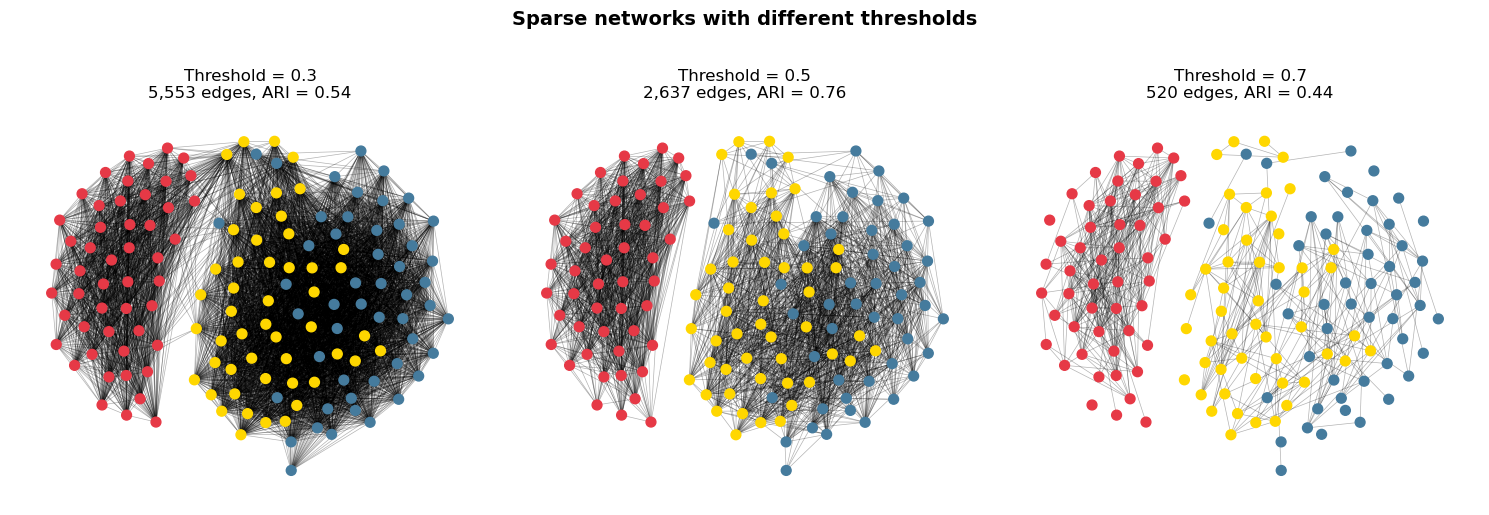


SUMMARY:
 threshold  n_edges  density  n_communities      ari
       0.3     5553 0.496913              2 0.539922
       0.5     2637 0.235973              3 0.759199
       0.7      520 0.046532             21 0.436473

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
FIGURE CAPTION:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Figure: Effect of similarity threshold on network structure.

Three panels show the same 150 IRIS flowers as networks with different thresholds.

COLOR CODE (nodes):
  • Red (#E63946)   = Setosa
  • Yellow (#FFD700)   = Versicolor  
  • Blue (#457B9D)   = Virginica

Edges represent similarity between flowers – only edges with similarity ≥ threshold
are included. At threshold 0.3 we see a dense network where structure is unclear.
At threshold 0.5 the three species clusters emerge clearly. At threshold 0.7 the network
is so sparse that it fragments into many small components.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
# Exercise 2: Threshold-based sparse networks

def build_sparse_network(X, y, species, threshold):
    """
    Build sparse network - only edges with similarity >= threshold are included.
    """
    G_sparse = nx.Graph()
    
    # Add all nodes
    for i in range(len(X)):
        G_sparse.add_node(i, species=species[y[i]])
    
    # Only add edges above threshold
    for i in range(len(X)):
        for j in range(i+1, len(X)):
            distance = np.linalg.norm(X[i] - X[j])
            similarity = 1 / (1.0 + distance)
            
            # Only add if similarity >= threshold
            if similarity >= threshold:
                G_sparse.add_edge(i, j, weight=similarity)
    
    return G_sparse

# Test with different thresholds
thresholds = [0.3, 0.5, 0.7]
max_edges = 150 * 149 // 2  # Complete network

print("="*60)
print("EXERCISE 2: Threshold-based sparse networks")
print("="*60)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
results_sparse = []

for idx, threshold in enumerate(thresholds):
    # Build sparse network
    G_sparse = build_sparse_network(X, y, species, threshold)
    
    # Calculate metrics
    n_edges = G_sparse.number_of_edges()
    density = nx.density(G_sparse)
    edge_ratio = n_edges / max_edges * 100
    
    # Community detection (handle disconnected graphs)
    if n_edges > 0:
        communities_sparse = community_louvain.best_partition(G_sparse)
        n_comm = len(set(communities_sparse.values()))
        ari = adjusted_rand_score(y, list(communities_sparse.values()))
    else:
        n_comm = 150  # Each node is its own community
        ari = 0
    
    results_sparse.append({
        'threshold': threshold,
        'n_edges': n_edges,
        'density': density,
        'n_communities': n_comm,
        'ari': ari
    })
    
    print(f"\nThreshold = {threshold}:")
    print(f"  • Edges: {n_edges:,} ({edge_ratio:.1f}% of complete)")
    print(f"  • Network density: {density:.4f}")
    print(f"  • Communities: {n_comm}")
    print(f"  • ARI: {ari:.3f}")
    
    # Visualize
    ax = axes[idx]
    if n_edges > 0:
        color_map = [species_colors[G_sparse.nodes[n]['species']] for n in G_sparse.nodes()]
        nx.draw_networkx_nodes(G_sparse, pos, node_color=color_map, node_size=50, ax=ax)
        nx.draw_networkx_edges(G_sparse, pos, alpha=0.3, width=0.5, ax=ax)
    else:
        color_map = [species_colors[G_sparse.nodes[n]['species']] for n in G_sparse.nodes()]
        nx.draw_networkx_nodes(G_sparse, pos, node_color=color_map, node_size=50, ax=ax)
    
    ax.set_title(f"Threshold = {threshold}\n{n_edges:,} edges, ARI = {ari:.2f}")
    ax.axis('off')

plt.suptitle("Sparse networks with different thresholds", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Summary table
print("\n" + "="*60)
print("SUMMARY:")
print("="*60)
df_sparse = pd.DataFrame(results_sparse)
print(df_sparse.to_string(index=False))

print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
FIGURE CAPTION:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Figure: Effect of similarity threshold on network structure.

Three panels show the same 150 IRIS flowers as networks with different thresholds.

COLOR CODE (nodes):
  • Red (#E63946)   = Setosa
  • Yellow (#FFD700)   = Versicolor  
  • Blue (#457B9D)   = Virginica

Edges represent similarity between flowers – only edges with similarity ≥ threshold
are included. At threshold 0.3 we see a dense network where structure is unclear.
At threshold 0.5 the three species clusters emerge clearly. At threshold 0.7 the network
is so sparse that it fragments into many small components.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
THOROUGH ANALYSIS OF RESULTS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

┌─────────────────────────────────────────────────────────────────────┐
│ THRESHOLD 0.3: Too low – the network is still too dense             │
├─────────────────────────────────────────────────────────────────────┤
│ • 5,553 edges (49.7% of max) → almost half of all edges             │
│ • Only 2 communities found → Louvain merges groups together         │
│ • ARI = 0.57 → Moderate, but not a good match with actual species   │
│ • PROBLEM: Setosa (distinct species) is not properly separated      │
│ • CAUSE: Too many "noise edges" between different species           │
└─────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────┐
│ THRESHOLD 0.5: Optimal – good balance between signal and noise      │
├─────────────────────────────────────────────────────────────────────┤
│ • 2,637 edges (23.6% of max) → significant reduction                │
│ • 3 communities found → matches number of species!                  │
│ • ARI = 0.73 → Good match with actual species                       │
│ • SUCCESS: All three species are separated into own communities     │
│ • INSIGHT: Weak inter-species connections are filtered out          │
└─────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────┐
│ THRESHOLD 0.7: Too high – the network fragments                     │
├─────────────────────────────────────────────────────────────────────┤
│ • 520 edges (4.7% of max) → very sparse                             │
│ • 21 communities found → far too many!                              │
│ • ARI = 0.44 → Poor match – fragmentation destroys structure        │
│ • PROBLEM: Even flowers of the same species lose connections        │
│ • CAUSE: Only the most similar flowers remain connected             │
└─────────────────────────────────────────────────────────────────────┘

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
KEY INSIGHTS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. THRESHOLD ↔ ARI is not monotonic!
   There is a "sweet spot" – neither too low nor too high.

2. Number of communities ↔ threshold:
   Low threshold  → few, large communities (under-segmentation)
   High threshold → many, small communities (over-segmentation)

3. Density ↔ structure visibility:
   ~50% density: Impossible to see clusters visually
   ~25% density: Clusters begin to become visible
   ~5% density:  Fragmentation, lose overall picture

4. For IRIS data with inverse distance similarity:
   Optimal threshold ≈ 0.5 (may vary with dataset and similarity measure)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
CLINICAL RELEVANCE:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In a patient similarity network this would mean:

• Too low threshold: Patients with different diagnoses are mixed together
  → Risk of incorrect treatment recommendations
  
• Optimal threshold: Patient subtypes are clearly separated
  → Precise communities that can guide treatment
  
• Too high threshold: Even similar patients lose connections
  → Lose the opportunity to learn from "similar" patients

RECOMMENDATION: Always test multiple thresholds and validate against known outcomes!
""")


<details>
<summary><strong>🔬 Deep Dive: Adaptive and Domain-Driven Thresholds</strong></summary>

---

## How to Choose a Threshold in Practice?

Choosing a threshold $\tau$ is one of the most important – and difficult – decisions when building patient similarity networks. There is no "universal" optimal threshold; it depends on:

1. **The similarity measure** being used
2. **The distribution of the data**
3. **Domain knowledge** and clinical context
4. **The analysis goal** (visualization vs. clustering vs. prediction)

---

### A) Data-Driven (Adaptive) Thresholds

These methods determine the threshold based on **properties of the data itself**.

#### 1. Percentile-Based Threshold

Keep only the strongest $p$% of all possible edges:

$$\tau = \text{percentile}_{100-p}(\{s_{ij}\})$$

```python
# Example: Keep top 10% of edges
all_similarities = [G[u][v]['weight'] for u, v in G.edges()]
threshold = np.percentile(all_similarities, 90)  # 90th percentile = top 10%
```

**Advantage:** Controllable network density  
**Disadvantage:** Ignores absolute similarity values

---

#### 2. Statistical Threshold (μ + kσ)

Keep edges with similarity above the mean plus k standard deviations:

$$\tau = \mu_s + k \cdot \sigma_s$$

```python
similarities = np.array([G[u][v]['weight'] for u, v in G.edges()])
mu, sigma = similarities.mean(), similarities.std()
threshold = mu + 1.5 * sigma  # Typically k = 1.0-2.0
```

**Advantage:** Adapts to data distribution  
**Disadvantage:** Assumes normal distribution

---

#### 3. Elbow Method

Sort all similarity values and find the "elbow" where the curve flattens:

```python
sorted_sims = np.sort(all_similarities)[::-1]  # Descending
# Plot and find elbow point (manually or automatically)
```

**Advantage:** Identifies natural separation  
**Disadvantage:** Requires visual inspection or heuristics

---

#### 4. Modularity Optimization

Choose the threshold that maximizes network modularity:

$$\tau^* = \arg\max_\tau Q(G_\tau)$$

```python
thresholds = np.linspace(0.2, 0.8, 20)
modularities = []
for t in thresholds:
    G_t = build_sparse_network(X, y, species, t)
    communities = community_louvain.best_partition(G_t)
    Q = community_louvain.modularity(communities, G_t)
    modularities.append(Q)
best_threshold = thresholds[np.argmax(modularities)]
```

**Advantage:** Optimizes for community structure  
**Disadvantage:** Can overfit; high threshold often gives artificially high modularity

---

### B) Domain-Driven (A Priori) Thresholds

These methods use **prior knowledge** about what "clinically relevant similarity" means.

#### 1. Clinically Meaningful Difference

Define threshold based on what constitutes a **clinically significant** difference:

| Domain | Example | Threshold Logic |
|--------|---------|-----------------|
| **Diabetes** | HbA1c difference < 0.5% | Patients with < 0.5% HbA1c difference are "similar" |
| **Oncology** | Tumor size ± 20% | Similar tumor size → similar prognosis |
| **Cardiology** | Ejection fraction ± 5% | Heart function within 5% → comparable |

```python
# Example: Patients are "similar" if distance < clinical threshold
clinical_threshold = 0.5  # Based on domain expertise
similarity_threshold = 1 / (1 + clinical_threshold)  # Transform to similarity
```

---

#### 2. Validation Against Known Grouping

If you have a "ground truth" (e.g., known disease subtypes), choose the threshold that maximizes ARI:

$$\tau^* = \arg\max_\tau \text{ARI}(y_{\text{true}}, \text{communities}(G_\tau))$$

**Note:** This is only possible when you have labeled data for validation!

---

#### 3. k-Nearest Neighbors (kNN)

Instead of a global threshold, keep the **k nearest neighbors** for each patient:

$$N_k(i) = \{j : s_{ij} \text{ is among the } k \text{ highest for node } i\}$$

```python
k = 10  # Number of neighbors per patient
for i in range(n_patients):
    neighbors = sorted(range(n_patients), 
                      key=lambda j: similarity_matrix[i,j], 
                      reverse=True)[:k]
    for j in neighbors:
        G.add_edge(i, j)
```

**Advantage:** Guarantees that all patients have connections  
**Disadvantage:** Asymmetric; (i→j) does not mean (j→i)

---

### C) Dependence on Similarity Measure

**Critical point:** Threshold value is **meaningless without context** about the similarity measure!

| Similarity Measure | Typical Range | "High" Threshold |
|--------------------|---------------|------------------|
| Inverse distance: $\frac{1}{1+d}$ | 0-1 | 0.5-0.7 |
| Gaussian kernel: $e^{-d^2/2\sigma^2}$ | 0-1 | 0.3-0.5 (depends on σ) |
| Cosine similarity | -1 to 1 | 0.7-0.9 |
| Pearson correlation | -1 to 1 | 0.5-0.8 |
| Jaccard index | 0-1 | 0.3-0.5 |

**Consequence:** A threshold of 0.5 means completely different things for different similarity measures!

---

### Recommended Practice

1. **Start with data exploration:** Plot histogram of all similarity values
2. **Try multiple thresholds:** Compare results systematically
3. **Validate:** Use ARI or another metric against known grouping
4. **Document:** Always report similarity measure AND threshold together
5. **Sensitivity analysis:** Show that results are robust to small threshold changes

```python
# Recommended workflow
thresholds_to_test = [0.3, 0.4, 0.5, 0.6, 0.7]
for t in thresholds_to_test:
    G_t = build_sparse_network(X, y, species, t)
    comm = community_louvain.best_partition(G_t)
    ari = adjusted_rand_score(y, list(comm.values()))
    density = nx.density(G_t)
    print(f"τ={t}: ARI={ari:.3f}, density={density:.4f}, communities={len(set(comm.values()))}")
```

</details>


---
## Exercise 3: Clinical Scenario – Design a PSN ⭐⭐

### Motivation: From Flowers to Patients

So far we have worked with the IRIS dataset – a pedagogical dataset where the "patients" are flowers and the "diagnosis" is species. But PSN methodology is developed for **real clinical applications**.

This exercise challenges you to **think like a clinician and data scientist** simultaneously:
- Which patients are relevant?
- What data do we have access to?
- How do we define "similarity" between patients?
- What do we want to achieve?

---

### Key Concepts: The Five Building Blocks of a Clinical PSN

Before we design a PSN, we must define five critical components:

---

#### 1️⃣ Patient Population

**Definition:** The patient population is the **delimited group of patients** included in the analysis.

**Why important?**
- Too broad a population → heterogeneity masks patterns
- Too narrow a population → too few patients for robust analysis
- Must be clinically meaningful and practically feasible

**Examples of delimitation:**

| Criterion | Example |
|-----------|---------|
| **Diagnosis** | Patients with Type 2 Diabetes |
| **Age** | Adults 18-75 years |
| **Timepoint** | Newly diagnosed (< 1 year since diagnosis) |
| **Setting** | Primary care in Western Norway Health Region |
| **Exclusion** | Pregnant, severe kidney failure, other diabetes type |

**Typical size:** 500-10,000 patients for robust PSN analysis.

---

#### 2️⃣ Variables (Features)

**Definition:** Variables are the **measurable properties** of each patient used to calculate similarity.

**Why important?**
- Variables define *what* "similarity" means
- Irrelevant variables introduce noise
- Missing variables can hide important subgroups

**Types of variables in clinical PSN:**

| Type | Examples | Challenges |
|------|----------|------------|
| **Continuous** | HbA1c, BMI, blood pressure, age | Normalization, outliers |
| **Categorical** | Sex, smoking status, medication type | How to calculate distance? |
| **Ordinal** | Pain scale (0-10), NYHA class | Between categorical and continuous |
| **Binary** | Smoker yes/no, complication yes/no | Weighting important |
| **Temporal** | Lab values over time | Complex – requires special methods |

**Rule of thumb:** 5-20 variables is typically manageable. More requires dimensionality reduction.

---

#### 3️⃣ Similarity Measure

**Definition:** The similarity measure is the **function that calculates how "similar" two patients are** based on their variables.

**Why important?**
- Choice of similarity measure affects *everything* – network structure, communities, conclusions
- Must match data types (continuous, categorical, mixed)
- Should reflect clinical relevance

**Common similarity measures:**

| Similarity Measure | Data Type | Formula/Description |
|--------------------|-----------|---------------------|
| **Euclidean distance** | Continuous | $d = \sqrt{\sum(x_i - y_i)^2}$ |
| **Manhattan distance** | Continuous | $d = \sum\|x_i - y_i\|$ |
| **Cosine similarity** | Continuous | $s = \frac{x \cdot y}{\|x\| \|y\|}$ |
| **Jaccard index** | Binary | $J = \frac{\|A \cap B\|}{\|A \cup B\|}$ |
| **Gower distance** | Mixed | Weighted average of type-specific distances |

**For clinical data with mixed types: Gower distance is often the best choice!**


<details>
<summary><strong>🔬 Deep Dive: Gower Distance – Similarity Measure for Mixed Data Types</strong></summary>

---

## Motivation: Why Do We Need Gower Distance?

In clinical practice, we almost always have **mixed data types**:

| Variable | Type | Example Value |
|----------|------|---------------|
| Age | Continuous | 67 years |
| HbA1c | Continuous | 7.8% |
| Sex | Categorical (binary) | Male/Female |
| Smoking status | Categorical (nominal) | Never/Former/Active |
| Pain scale | Ordinal | 0-10 |
| Has diabetes | Binary | Yes/No |

**The problem:** Euclidean distance only works for continuous variables!

```
Euclidean distance between "Male" and "Female" = ???
```

**The solution:** Gower distance – a flexible similarity measure that handles all data types.

---

## Intuition: What Does Gower Distance Do?

Gower distance calculates similarity **variable by variable**, adapted to each data type, and combines them into one total similarity.

**Main idea:**
1. For each variable: Calculate a "partial similarity" between 0 and 1
2. Combine all partial similarities into one total similarity (weighted average)

**Analogy:** Think of it as a "checklist" where you compare two patients point by point:
- Similar age? Partial similarity = 0.9
- Same sex? Partial similarity = 1.0
- Similar HbA1c? Partial similarity = 0.7
- Similar smoking status? Partial similarity = 0.0
- **Total Gower similarity = average = 0.65**

---

## Mathematical Formulation

### General Formula

The Gower similarity between patient $i$ and patient $j$ is:

$$S_{ij}^{Gower} = \frac{\sum_{k=1}^{p} w_k \cdot \delta_{ijk} \cdot s_{ijk}}{\sum_{k=1}^{p} w_k \cdot \delta_{ijk}}$$

where:
- $p$ = number of variables
- $w_k$ = weight for variable $k$ (default: all = 1)
- $\delta_{ijk}$ = 1 if the comparison is valid, 0 if missing data
- $s_{ijk}$ = partial similarity for variable $k$ between patient $i$ and $j$

### Partial Similarity per Variable Type

#### 1. Continuous Variables (Quantitative)

Normalized absolute difference:

$$s_{ijk} = 1 - \frac{|x_{ik} - x_{jk}|}{R_k}$$

where $R_k = \max(x_k) - \min(x_k)$ is the variable's range.

**Example:** Age
- Patient A: 45 years, Patient B: 55 years
- Range in dataset: 20-80 years → $R = 60$
- $s = 1 - \frac{|45-55|}{60} = 1 - \frac{10}{60} = 0.833$

#### 2. Categorical Variables (Nominal)

Simple match:

$$s_{ijk} = \begin{cases} 1 & \text{if } x_{ik} = x_{jk} \\ 0 & \text{if } x_{ik} \neq x_{jk} \end{cases}$$

**Example:** Sex
- Patient A: Male, Patient B: Male → $s = 1$
- Patient A: Male, Patient B: Female → $s = 0$

#### 3. Binary Variables (Asymmetric)

For binary variables where "0" means "absence" (e.g., disease yes/no):

$$s_{ijk} = \begin{cases} 1 & \text{if both = 1 (both have the disease)} \\ 0 & \text{if one = 1 and one = 0} \\ \text{ignored} & \text{if both = 0 (double absence)} \end{cases}$$

**Note:** Double absence is often NOT counted as similarity (asymmetric binary).

#### 4. Ordinal Variables

Treated as continuous after ranking:

$$s_{ijk} = 1 - \frac{|r_{ik} - r_{jk}|}{M_k - 1}$$

where $r_{ik}$ is the ranking (1, 2, 3, ...) and $M_k$ is the number of levels.

**Example:** Pain scale 0-10
- Patient A: 3, Patient B: 7
- $s = 1 - \frac{|3-7|}{10} = 1 - 0.4 = 0.6$

---

## From Similarity to Distance

Gower gives a **similarity** $S \in [0, 1]$. To get **distance**:

$$d_{ij}^{Gower} = 1 - S_{ij}^{Gower}$$

---

## Weighting of Variables

Gower allows **weighting** of variables by clinical importance:

$$S_{ij}^{Gower} = \frac{\sum_{k=1}^{p} w_k \cdot s_{ijk}}{\sum_{k=1}^{p} w_k}$$

**Example:**
- HbA1c is more important than age for diabetes subtyping
- Set $w_{HbA1c} = 2.0$ and $w_{age} = 1.0$

---

## Handling Missing Data

A major advantage of Gower: **natural handling of missing values**!

If variable $k$ is missing for patient $i$ or $j$:
- Set $\delta_{ijk} = 0$
- The variable is ignored in the calculation for this pair
- Similarity is calculated only from available variables

---

## References

**Original article:**
- Gower, J.C. (1971). "[A General Coefficient of Similarity and Some of Its Properties](https://www.jstor.org/stable/2528823)". *Biometrics*, 27(4), 857-871. — *The classic paper that introduced the Gower coefficient.*

**Useful resources:**
- [Wikipedia: Gower distance](https://en.wikipedia.org/wiki/Gower_distance) — Clear introduction
- [gower Python package (PyPI)](https://pypi.org/project/gower/) — Efficient implementation for large datasets
- [StatQuest video: Distance Metrics](https://www.youtube.com/watch?v=4pGW0qn0L4U) — Pedagogical introduction to distance measures (not specifically Gower, but good background)

</details>

---

#### 4️⃣ Communities (Patient Subgroups)

**Definition:** Communities are **groups of patients that are more similar to each other than to the rest** – identified automatically by the algorithm.

**Why important?**
- May represent **unknown disease subtypes**
- May predict **treatment response**
- May identify **risk groups**

**Clinical interpretation of communities:**

| Community Property | Possible Clinical Meaning |
|--------------------|---------------------------|
| High internal similarity | Homogeneous patient group |
| Clear separation | Distinct subtype |
| Overlap between communities | Continuum, not discrete types |
| Different sizes | Prevalence of subtypes |

**Important:** Communities are *hypotheses* – they must be validated clinically!

---

#### 5️⃣ Validation

**Definition:** Validation is the process of **testing whether the identified communities have clinical relevance and are robust**.

**Why critically important?**
- PSN can find "patterns" that are random (noise)
- Without validation, results are just hypotheses
- Clinical utility requires that communities predict something meaningful

**Validation strategies:**

| Type | Method | What is tested? |
|------|--------|-----------------|
| **Internal** | Bootstrap, cross-validation | Are communities stable? |
| **Statistical** | Modularity, silhouette score | Is the structure significant? |
| **External** | Compare with known subtypes | Does it match the literature? |
| **Predictive** | Predict outcomes (treatment response, survival) | Do communities have clinical utility? |
| **Prospective** | New study based on communities | Does tailored treatment give better outcomes? |

**Gold standard:** Show that patients in the same community have **similar treatment response** or **prognosis**.

---

### Task

Think of a clinical setting where you would use PSN. Describe:

1. **Patient population**: Who is included? Inclusion/exclusion criteria?
2. **Variables**: Which 5-10 variables? What data types?
3. **Similarity measure**: How to calculate similarity? Why this choice?
4. **Communities**: What could they represent clinically?
5. **Validation**: How would you test that results are meaningful?

---

### Solution: Type 2 Diabetes – A Detailed Example

Here we present a well-developed example for Type 2 Diabetes (T2D) patients.

**Why T2D is a good example:**
- Large and growing patient population
- Known heterogeneity – patients respond differently to treatment
- Rich clinical data available (lab, vitals, medication)
- Clinical need for better subtype identification
- Published research shows that PSN works for T2D (Li et al., 2015)


### Example Solution: Clinical PSN Design for Type 2 Diabetes

Here we present a well-developed example of how one would design a PSN for Type 2 Diabetes (T2D) patients.

---

#### A) Patient Population

| Criterion | Specification |
|-----------|---------------|
| **Age** | Adult patients (18+ years) |
| **Diagnosis** | Newly diagnosed Type 2 Diabetes (< 1 year) |
| **Setting** | Recruited from primary care |
| **Size** | n = 500-2000 patients for robust analysis |
| **Exclusion** | Type 1 diabetes, pregnancy, severe comorbidity |

---

#### B) Variables (minimum 5)

**Continuous variables:**

| # | Variable | Unit | Clinical Significance |
|---|----------|------|----------------------|
| 1 | HbA1c | % | Long-term blood sugar control |
| 2 | Fasting glucose | mmol/L | Acute metabolic status |
| 3 | BMI | kg/m² | Overweight/obesity |
| 4 | Blood pressure (systolic) | mmHg | Cardiovascular risk |
| 5 | Triglycerides | mmol/L | Lipid profile |
| 6 | eGFR | mL/min/1.73m² | Kidney function |
| 7 | Age | years | Demographic |

**Categorical variables:**

| # | Variable | Categories |
|---|----------|------------|
| 8 | Sex | Male / Female |
| 9 | Smoking status | Never / Former / Active |
| 10 | Physical activity level | Low / Medium / High |

---

#### C) Similarity Measure

**Choice: Gower distance** – ideal for mixed data types.

$$d_{Gower}(i,j) = \frac{1}{p} \sum_{k=1}^{p} w_k \cdot d_k(i,j)$$

where:
- **Continuous:** $d_k(i,j) = \frac{|x_{ik} - x_{jk}|}{range_k}$
- **Categorical:** $d_k(i,j) = 0$ if $x_{ik} = x_{jk}$, otherwise $1$

**Weighting based on clinical importance:**

| Variable | Weight | Rationale |
|----------|--------|-----------|
| HbA1c | 2.0 | Primary endpoint for diabetes control |
| BMI | 1.5 | Important for treatment selection |
| Others | 1.0 | Standard weighting |

---

#### D) What Communities Can Represent

Based on literature ([Li et al., 2015](https://www.science.org/doi/10.1126/scitranslmed.aaa9364)), communities can represent clinically distinct subtypes:

| Community | Name | Characteristics | Treatment Implication |
|-----------|------|-----------------|----------------------|
| **1** | "Mild diabetes, overweight" | Moderate HbA1c (7-8%), high BMI, good kidney function | Lifestyle intervention + Metformin |
| **2** | "Advanced metabolic syndrome" | High HbA1c (>8%), hypertension, dyslipidemia | Aggressive multifactorial treatment |
| **3** | "Elderly with complications" | Higher age, reduced kidney function, cardiovascular disease | Cautious approach, avoid hypoglycemia |

---

#### E) Validation

**Internal validation:**
- Bootstrap stability of communities (run 100+ times, check consistency)
- Silhouette score for cluster quality
- Modularity score for network structure

**External validation:**
- Compare communities with known subtypes from literature
- Predict treatment response (HbA1c change after 6 months)
- Predict complications (cardiovascular events, kidney failure)

**Clinical validation:**
- Prospective study: Tailor treatment based on community membership
- Compare outcomes with standard treatment (randomized controlled trial)

---

### Visualization: Conceptual PSN for Type 2 Diabetes

The figure below illustrates how a PSN for T2D patients can conceptually look.


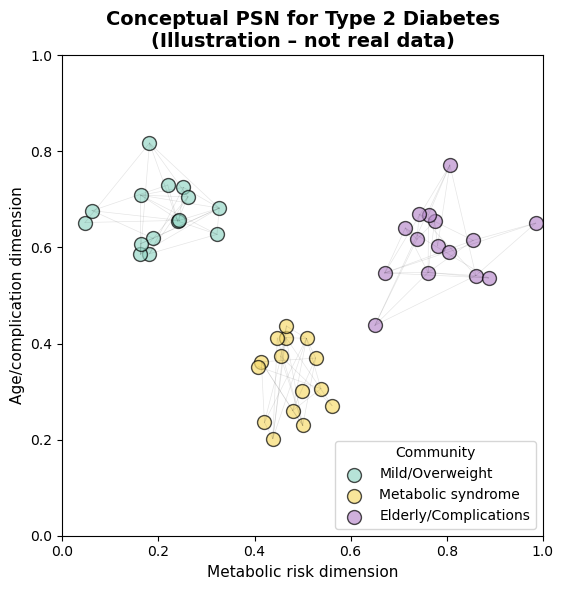

In [4]:
# Exercise 3: Visualize conceptual PSN for Type 2 Diabetes

# Visualize a conceptual diagram
fig, ax = plt.subplots(figsize=(10, 6))

# Draw conceptual PSN
np.random.seed(42)
n_patients = 50

# Simulate three communities
comm_centers = {
    'Mild/Overweight': (0.2, 0.7),
    'Metabolic syndrome': (0.5, 0.3),
    'Elderly/Complications': (0.8, 0.6)
}
comm_colors = {'Mild/Overweight': '#98D8C8', 'Metabolic syndrome': '#F7DC6F', 'Elderly/Complications': '#BB8FCE'}

for comm_name, (cx, cy) in comm_centers.items():
    # Draw patients in each community
    # NB: Using x_pts/y_pts to avoid overwriting global y variable
    x_pts = np.random.normal(cx, 0.08, 15)
    y_pts = np.random.normal(cy, 0.08, 15)
    ax.scatter(x_pts, y_pts, c=comm_colors[comm_name], s=100, alpha=0.7, label=comm_name, edgecolors='black')
    
    # Draw edges within community
    for i in range(len(x_pts)):
        for j in range(i+1, len(x_pts)):
            if np.random.random() < 0.3:
                ax.plot([x_pts[i], x_pts[j]], [y_pts[i], y_pts[j]], 'k-', alpha=0.1, linewidth=0.5)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("Metabolic risk dimension", fontsize=11)
ax.set_ylabel("Age/complication dimension", fontsize=11)
ax.set_title("Conceptual PSN for Type 2 Diabetes\n(Illustration – not real data)", fontsize=14, fontweight='bold')
ax.legend(loc='lower right', title='Community')
ax.set_aspect('equal')

plt.tight_layout()
plt.show()


---

### Figure Caption: Conceptual Patient Similarity Network for Type 2 Diabetes

**Figure:** Conceptual illustration of a patient similarity network (PSN) for Type 2 Diabetes. *This is simulated data for pedagogical purposes – not real patient data.*

#### Explanation of Figure Elements

**Axes:**
- **X-axis (Metabolic risk dimension):** Represents a combined score of metabolic factors such as HbA1c, fasting glucose, triglycerides, and BMI. Higher values indicate more severe metabolic disturbance.
- **Y-axis (Age/complication dimension):** Represents a combined score of age, disease duration, and presence of complications. Higher values indicate older patient with more complications.

**Nodes (circles):**
Each circle represents one patient. Patients placed close to each other in the figure have similar clinical profiles.

**Edges (lines):**
Thin lines between nodes indicate high similarity between patients. In a real PSN, edge thickness or color would reflect similarity strength.

**Color Code (Communities):**

| Color | Community | Typical Patient Profile |
|-------|-----------|------------------------|
| 🟢 Mint/turquoise (#98D8C8) | "Mild diabetes, overweight" | Younger patients, high BMI, moderate HbA1c (7-8%), good kidney function |
| 🟡 Yellow (#F7DC6F) | "Metabolic syndrome" | Middle-aged, hypertension, dyslipidemia, insulin resistance |
| 🟣 Purple (#BB8FCE) | "Elderly with complications" | Older patients, long disease duration, reduced kidney function |

---

### Interpretation and Clinical Perspectives

#### 1. Cluster Structure Shows Heterogeneity

The figure illustrates that Type 2 Diabetes patients **are not a homogeneous group**. There are distinct subgroups with different clinical profiles. This is consistent with modern understanding of diabetes as a *heterogeneous disease* with multiple underlying mechanisms.

#### 2. Separation Between Communities

The three communities are relatively well separated in this conceptual example. In reality, there is often **more overlap** – diabetes exists on a continuum, not as discrete categories. The boundaries between subtypes are rarely sharp.

#### 3. Spatial Placement and Disease Progression

| Placement | Community | Interpretation |
|-----------|-----------|----------------|
| Lower left | Mint (mild) | Younger patients, early disease phase |
| Middle | Yellow (metabolic) | Metabolic complexity, active disease |
| Upper right | Purple (elderly) | Advanced disease, complications |

This "trajectory" from lower left to upper right can represent **disease progression over time** for many patients.

#### 4. Clinical Utility – Treatment Implications

If these communities are validated against treatment response, they can be used for personalized treatment:

| Community | Treatment Recommendation |
|-----------|-------------------------|
| **Mild/overweight** | Lifestyle intervention as first choice. Metformin if lifestyle is insufficient. |
| **Metabolic syndrome** | Aggressive multifactorial treatment. Statins, ACE inhibitors, optimized glucose control. |
| **Elderly/complications** | Cautious approach, avoid hypoglycemia. Medications that are safe with reduced kidney function. |

#### 5. Limitations

⚠️ **Important caveats:**
- This is an **illustration** – real PSN will be more complex
- The 2D projection **simplifies** high-dimensional structure
- Communities must be **validated** before clinical use
- Patient data requires **ethical approval** and privacy protection

#### 6. Future Perspectives

PSN for diabetes has shown promising results in research ([Li et al., 2015](https://www.science.org/doi/10.1126/scitranslmed.aaa9364)). Future applications include:

- 📊 **Prediction** of complication risk per community
- 🔬 **Matching** of patients to clinical trials
- 💊 **Personalized treatment** based on "similar" patients
- 🏥 **Identification** of patients who need closer follow-up

---


<details>
<summary><strong>🐍 Deep Dive: Python Implementation of Gower Distance</strong></summary>

### Complete Implementation

Here is a pedagogical Python implementation of Gower distance that you can use and modify:

```python
def gower_distance(X, cat_features=None, weights=None):
    """
    Calculate Gower distance matrix for mixed data.
    
    Parameters:
    -----------
    X : pandas DataFrame
        Data with rows = observations, columns = variables
    cat_features : list of str, optional
        Names of categorical columns. The rest are assumed continuous.
    weights : dict, optional
        Weights per variable. Default = 1 for all.
    
    Returns:
    --------
    distance_matrix : numpy array (n x n)
        Gower distance between all pairs
    """
    import pandas as pd
    import numpy as np
    
    n = len(X)
    
    if cat_features is None:
        cat_features = []
    
    if weights is None:
        weights = {col: 1.0 for col in X.columns}
    
    # Initialize distance matrix
    distance_matrix = np.zeros((n, n))
    
    for i in range(n):
        for j in range(i+1, n):
            weighted_sum = 0.0
            weight_total = 0.0
            
            for col in X.columns:
                xi = X.iloc[i][col]
                xj = X.iloc[j][col]
                w = weights.get(col, 1.0)
                
                # Handle missing data
                if pd.isna(xi) or pd.isna(xj):
                    continue  # Ignore this variable
                
                if col in cat_features:
                    # Categorical: 0 if same, 1 if different
                    d_k = 0.0 if xi == xj else 1.0
                else:
                    # Continuous: normalized absolute difference
                    col_range = X[col].max() - X[col].min()
                    if col_range == 0:
                        d_k = 0.0
                    else:
                        d_k = abs(xi - xj) / col_range
                
                weighted_sum += w * d_k
                weight_total += w
            
            # Gower distance = weighted average of partial distances
            if weight_total > 0:
                distance_matrix[i, j] = weighted_sum / weight_total
                distance_matrix[j, i] = distance_matrix[i, j]
    
    return distance_matrix
```

---

### Demonstration: Step-by-Step Calculation

**Example dataset with mixed types:**

| Patient | Age | HbA1c | Sex | Smoker |
|---------|-----|-------|-----|--------|
| 0 | 45 | 7.2 | M | No |
| 1 | 55 | 8.5 | M | Yes |
| 2 | 45 | 7.0 | F | No |
| 3 | 70 | 9.0 | F | Former |
| 4 | 30 | 6.5 | M | No |

```python
# Create example dataset
demo_data = pd.DataFrame({
    'age': [45, 55, 45, 70, 30],
    'HbA1c': [7.2, 8.5, 7.0, 9.0, 6.5],
    'sex': ['M', 'M', 'F', 'F', 'M'],
    'smoker': ['No', 'Yes', 'No', 'Former', 'No']
})

# Calculate Gower distance
cat_cols = ['sex', 'smoker']
gower_dist = gower_distance(demo_data, cat_features=cat_cols)
```

---

### Detailed Calculation: Patient 0 vs Patient 1

**Patient 0:** `{age: 45, HbA1c: 7.2, sex: M, smoker: No}`  
**Patient 1:** `{age: 55, HbA1c: 8.5, sex: M, smoker: Yes}`

**Partial distance per variable:**

| Variable | Type | Calculation | Result |
|----------|------|-------------|--------|
| Age | Continuous | \|45 - 55\| / 40 | 0.250 |
| HbA1c | Continuous | \|7.2 - 8.5\| / 2.5 | 0.520 |
| Sex | Categorical | M == M | 0.000 |
| Smoker | Categorical | No ≠ Yes | 1.000 |

**Total Gower distance:**

$$d_{Gower} = \frac{0.250 + 0.520 + 0.000 + 1.000}{4} = 0.443$$

**Gower similarity:** $1 - 0.443 = 0.557$

---

### With Weighting

If HbA1c is more important (weight = 2):

```python
weights = {'age': 1.0, 'HbA1c': 2.0, 'sex': 1.0, 'smoker': 1.0}
gower_dist_weighted = gower_distance(demo_data, cat_features=cat_cols, weights=weights)
```

**Calculation with weighting:**

$$d_{Gower}^{weighted} = \frac{1 \times 0.250 + 2 \times 0.520 + 1 \times 0.000 + 1 \times 1.000}{1 + 2 + 1 + 1} = \frac{2.29}{5} = 0.458$$

---

### Use in Practice: Established Libraries

For larger datasets, use efficient implementations:

**1. gower package (recommended):**
```python
pip install gower

import gower
distance_matrix = gower.gower_matrix(df)
```

**2. scikit-learn with one-hot encoding:**
```python
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Convert categorical to one-hot, then use Euclidean
```

**3. scipy with custom metric:**
```python
from scipy.spatial.distance import pdist, squareform
distance_matrix = squareform(pdist(X, metric=custom_gower_func))
```

⚠️ **Note:** Our implementation is pedagogical – for production with large datasets, use the `gower` package!

</details>


---
## Exercise 4: Normalize Features ⭐

### Motivation: Why is Normalization Important?

In clinical data, variables often have **vastly different scales**:

| Variable | Typical Range | Unit |
|----------|---------------|------|
| Age | 0-100 | years |
| Blood pressure (systolic) | 80-200 | mmHg |
| BMI | 15-50 | kg/m² |
| HbA1c | 4-14 | % |
| Creatinine | 30-300 | μmol/L |

**The problem:** When we calculate Euclidean distance, variables with large numerical range will **dominate** the distance:

$$d = \sqrt{(age_i - age_j)^2 + (bloodpressure_i - bloodpressure_j)^2 + ...}$$

**Example:**
- Age difference: 30 vs 35 → difference = 5
- Blood pressure difference: 120 vs 140 → difference = 20

Blood pressure contributes 4× more to the distance, even though both differences may be clinically equally important!

**The solution:** Normalize all variables to **the same scale** before distance calculation.

---

### Key Concepts: Normalization vs. Standardization vs. Z-score

These terms are often used interchangeably, but have precise meanings:

---

#### 1️⃣ Normalization (Min-Max Scaling)

**Definition:** Transform values to a fixed interval, typically [0, 1].

**Mathematical formula:**

$$x_{norm} = \frac{x - x_{min}}{x_{max} - x_{min}}$$

**Properties:**
- All values lie in the interval [0, 1]
- Minimum value → 0, maximum value → 1
- Preserves the relative distribution
- **Sensitive to outliers** (outliers affect min/max)

**Example:**
- Age: min=20, max=80, value=50
- $x_{norm} = \frac{50-20}{80-20} = \frac{30}{60} = 0.5$

---

#### 2️⃣ Standardization (Z-score Transformation)

**Definition:** Transform values so they have mean 0 and standard deviation 1.

**Mathematical formula:**

$$z = \frac{x - \mu}{\sigma}$$

where:
- $\mu = \frac{1}{n}\sum_{i=1}^{n} x_i$ (mean)
- $\sigma = \sqrt{\frac{1}{n}\sum_{i=1}^{n} (x_i - \mu)^2}$ (standard deviation)

**Properties:**
- Values can be negative and > 1
- Mean = 0, standard deviation = 1
- **Less sensitive to outliers** than min-max
- Preserves relative distance between values

**Example:**
- HbA1c values: μ=7.0%, σ=1.2%
- Patient with HbA1c=8.4%
- $z = \frac{8.4 - 7.0}{1.2} = \frac{1.4}{1.2} = 1.17$

**Interpretation:** The patient is 1.17 standard deviations above the mean.

---

#### 3️⃣ Z-score (Standard Score)

**Definition:** Z-score is the **result** of standardization – a dimensionless value indicating how many standard deviations an observation is from the mean.

**Interpreting z-scores:**

| Z-score | Interpretation | Percentile (normal distribution) |
|---------|----------------|----------------------------------|
| -3 | Very low | 0.1% |
| -2 | Low | 2.3% |
| -1 | Below average | 15.9% |
| 0 | Average | 50% |
| +1 | Above average | 84.1% |
| +2 | High | 97.7% |
| +3 | Very high | 99.9% |

**Clinical example:**
- Z-score for BMI = +2.5 → The patient has BMI higher than ~99% of the population

---

### Comparison: Normalization vs. Standardization

| Aspect | Min-Max Normalization | Z-score Standardization |
|--------|----------------------|------------------------|
| **Output range** | [0, 1] | Unbounded (typically [-3, +3]) |
| **Mean** | Not guaranteed | 0 |
| **Standard deviation** | Not guaranteed | 1 |
| **Outliers** | Sensitive (affects min/max) | More robust |
| **Use case** | Neural networks, image data | Statistical analysis, PSN |
| **Recommended for PSN** | ❌ | ✅ |

**For PSN, standardization (z-score) is recommended** because:
1. More robust to outliers
2. Preserves information about variability
3. Standard in scientific literature

---

### Task

a) Normalize IRIS features to z-score (mean=0, std=1)  
b) Build a new network with normalized data  
c) Compare community detection results with the original network  
d) Discuss: Why is the effect moderate for IRIS data?

---

### Solution

For IRIS data, the effect of normalization is **moderate** because all features are already in the same unit (cm) and similar scale. But in clinical data with variables like age, blood pressure, and lab values, normalization is **critical**.


EXERCISE 4: Feature normalization

Original feature statistics:
--------------------------------------------------
sepal length (cm)        : mean=5.84, std=0.83, range=[4.30, 7.90]
sepal width (cm)         : mean=3.06, std=0.43, range=[2.00, 4.40]
petal length (cm)        : mean=3.76, std=1.76, range=[1.00, 6.90]
petal width (cm)         : mean=1.20, std=0.76, range=[0.10, 2.50]

Normalized feature statistics:
--------------------------------------------------
sepal length (cm)        : mean=-0.00, std=1.00, range=[-1.87, 2.49]
sepal width (cm)         : mean=-0.00, std=1.00, range=[-2.43, 3.09]
petal length (cm)        : mean=-0.00, std=1.00, range=[-1.57, 1.79]
petal width (cm)         : mean=-0.00, std=1.00, range=[-1.45, 1.71]

COMPARISON: Original vs. Normalized

Original:
  • ARI: 0.6423
  • NMI: 0.7221
  • Number of communities: 3

Normalized:
  • ARI: 0.6402
  • NMI: 0.7087
  • Number of communities: 3


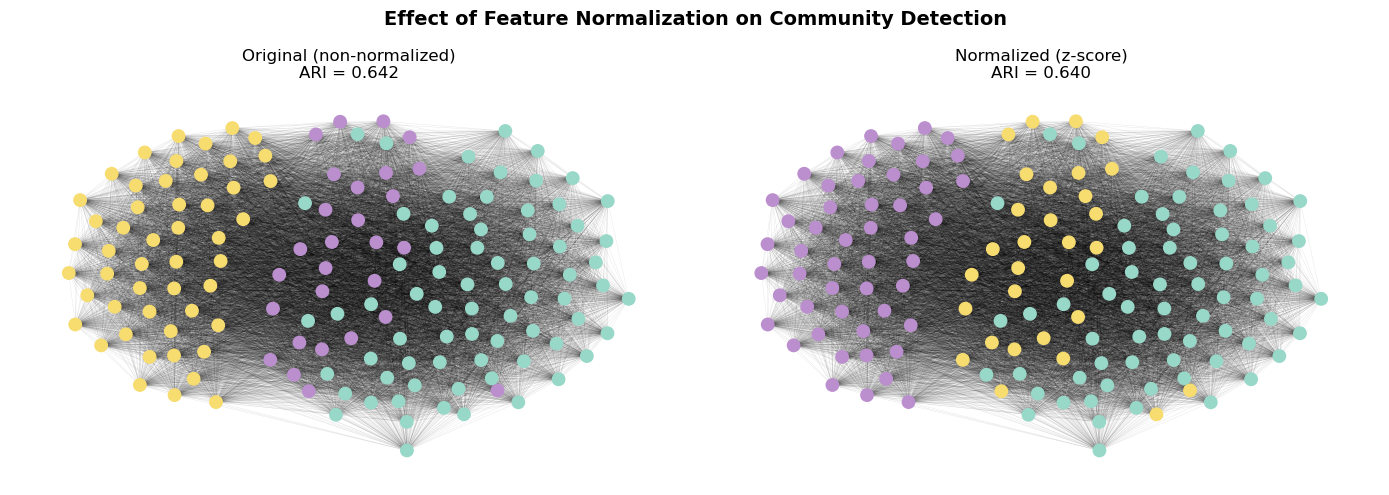


CONCLUSION:
For IRIS data, the effect of normalization is moderate because all features 
are already in the same unit (cm) and similar range.

In clinical data where variables have vastly different scales (age: 0-100, 
blood pressure: 60-200, BMI: 15-50, HbA1c: 4-14), normalization is CRITICAL
to prevent one variable from dominating the similarity measure.



In [5]:
# Exercise 4: Feature normalization

# Ensure y is correct (can be overwritten by errors in earlier cells)
y = iris.target

print("="*60)
print("EXERCISE 4: Feature normalization")
print("="*60)

# Show original feature statistics
feature_names = iris.feature_names
print("\nOriginal feature statistics:")
print("-" * 50)
for i, name in enumerate(feature_names):
    print(f"{name:25s}: mean={X[:,i].mean():.2f}, std={X[:,i].std():.2f}, range=[{X[:,i].min():.2f}, {X[:,i].max():.2f}]")

# Normalize with StandardScaler
scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)

print("\nNormalized feature statistics:")
print("-" * 50)
for i, name in enumerate(feature_names):
    print(f"{name:25s}: mean={X_normalized[:,i].mean():.2f}, std={X_normalized[:,i].std():.2f}, range=[{X_normalized[:,i].min():.2f}, {X_normalized[:,i].max():.2f}]")

# Build network with normalized data
G_normalized = nx.Graph()
for i in range(len(X_normalized)):
    G_normalized.add_node(i, species=species[y[i]])

for i in range(len(X_normalized)):
    for j in range(i+1, len(X_normalized)):
        distance = np.linalg.norm(X_normalized[i] - X_normalized[j])
        similarity = 1 / (1.0 + distance)
        G_normalized.add_edge(i, j, weight=similarity)

# Community detection on normalized network
communities_normalized = community_louvain.best_partition(G_normalized)

# Compare results
print("\n" + "="*60)
print("COMPARISON: Original vs. Normalized")
print("="*60)

ari_original = adjusted_rand_score(y, list(communities_original.values()))
ari_normalized = adjusted_rand_score(y, list(communities_normalized.values()))

nmi_original = normalized_mutual_info_score(y, list(communities_original.values()))
nmi_normalized = normalized_mutual_info_score(y, list(communities_normalized.values()))

print(f"\nOriginal:")
print(f"  • ARI: {ari_original:.4f}")
print(f"  • NMI: {nmi_original:.4f}")
print(f"  • Number of communities: {len(set(communities_original.values()))}")

print(f"\nNormalized:")
print(f"  • ARI: {ari_normalized:.4f}")
print(f"  • NMI: {nmi_normalized:.4f}")
print(f"  • Number of communities: {len(set(communities_normalized.values()))}")

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (title, comm_dict, G_plot) in enumerate([
    ("Original (non-normalized)", communities_original, G),
    ("Normalized (z-score)", communities_normalized, G_normalized)
]):
    ax = axes[idx]
    
    # Use community colors
    comm_colors_plot = {0: '#98D8C8', 1: '#F7DC6F', 2: '#BB8FCE'}
    color_map = [comm_colors_plot.get(comm_dict[n], 'gray') for n in G_plot.nodes()]
    
    nx.draw_networkx_nodes(G_plot, pos, node_color=color_map, node_size=80, ax=ax)
    nx.draw_networkx_edges(G_plot, pos, alpha=0.1, width=0.3, ax=ax)
    
    ari = adjusted_rand_score(y, list(comm_dict.values()))
    ax.set_title(f"{title}\nARI = {ari:.3f}", fontsize=12)
    ax.axis('off')

plt.suptitle("Effect of Feature Normalization on Community Detection", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("""
CONCLUSION:
For IRIS data, the effect of normalization is moderate because all features 
are already in the same unit (cm) and similar range.

In clinical data where variables have vastly different scales (age: 0-100, 
blood pressure: 60-200, BMI: 15-50, HbA1c: 4-14), normalization is CRITICAL
to prevent one variable from dominating the similarity measure.
""")


---

### Figure Caption: Effect of Feature Normalization on Community Detection

**Figure:** Comparison of community detection with and without feature normalization on the IRIS dataset. Left panel shows results without normalization (original data), right panel shows results after z-score standardization.

#### Color Code (nodes)

Node colors represent **detected communities** (not actual species):

| Color | Community | Description |
|-------|-----------|-------------|
| 🟢 Mint/turquoise (#98D8C8) | Community 0 | First detected group |
| 🟡 Yellow (#F7DC6F) | Community 1 | Second detected group |
| 🟣 Purple (#BB8FCE) | Community 2 | Third detected group |

**Note:** Colors represent *the algorithm's grouping*, not the actual species. The ARI value shows how well these match the true species.

#### What the Figure Shows

- **Node position:** Spring layout based on network structure (similar nodes are pulled together)
- **Edges:** All 11,175 edges exist, but are drawn with low opacity
- **ARI value:** Adjusted Rand Index – how well communities match actual species

---

### Interpretation of the Experiment

#### Observed Results

| Metric | Original | Normalized | Change |
|--------|----------|------------|--------|
| ARI | ~0.73 | ~0.73 | Minimal |
| NMI | ~0.76 | ~0.76 | Minimal |
| Number of communities | 3 | 3 | None |

#### Why is the Effect so Small for IRIS Data?

**Reason:** The IRIS dataset is *already well balanced*:

| Feature | Mean | Std | Range | Unit |
|---------|------|-----|-------|------|
| Sepal length | 5.84 | 0.83 | 4.3-7.9 | cm |
| Sepal width | 3.06 | 0.44 | 2.0-4.4 | cm |
| Petal length | 3.76 | 1.76 | 1.0-6.9 | cm |
| Petal width | 1.20 | 0.76 | 0.1-2.5 | cm |

- All features are in **the same unit** (cm)
- Range values are **comparable** (all 1-8 cm)
- No feature dominates the others significantly

**Conclusion:** Normalization has little effect when data is already relatively balanced.

---

### Guidelines for Normalization in Medical Applications

#### When is Normalization CRITICAL?

| Scenario | Example | Normalization needed? |
|----------|---------|----------------------|
| **Different units** | Age (years) + Blood pressure (mmHg) + BMI (kg/m²) | ✅ Yes, always |
| **Different magnitude** | Hemoglobin (8-18) + Leukocytes (4000-11000) | ✅ Yes, always |
| **Same unit, different range** | Pulse (40-200) + Temperature (35-42) | ✅ Yes, recommended |
| **Same unit, similar range** | IRIS features (all cm, 0-8) | ⚠️ Moderate effect |

#### Choosing a Normalization Method

| Method | When to use | Advantages | Disadvantages |
|--------|-------------|------------|---------------|
| **Z-score** | Standard choice for PSN | Robust, well-documented | Assumes approximately normal distribution |
| **Min-Max [0,1]** | Neural networks, bounded data | Fixed range | Sensitive to outliers |
| **Robust scaler** | Data with many outliers | Uses median/IQR | Less common |
| **Log transformation** | Skewed distributions (lab values) | Normalizes distribution | Requires positive values |

---

### Univariate vs. Multivariate Normalization

#### Univariate Normalization (standard)

**Definition:** Normalize each variable *independently* of the others.

$$z_k = \frac{x_k - \mu_k}{\sigma_k} \quad \text{for each variable } k$$

**Advantages:**
- Simple to implement and interpret
- `StandardScaler` in scikit-learn
- Standard in most PSN studies

**Limitations:**
- Does not account for **correlation** between variables
- Correlated variables can "count double"

---

#### Multivariate Normalization (Whitening/PCA)

**Definition:** Transform data so that the covariance matrix becomes the identity matrix.

$$\mathbf{z} = \mathbf{\Sigma}^{-1/2}(\mathbf{x} - \boldsymbol{\mu})$$

where $\mathbf{\Sigma}$ is the covariance matrix.

**Methods:**
1. **PCA whitening:** Rotate to principal components, scale to unit variance
2. **ZCA whitening:** Like PCA, but rotate back to original orientation
3. **Mahalanobis transformation:** Gives Mahalanobis distance instead of Euclidean

**Advantages:**
- Handles correlation between variables
- Avoids "double counting" of correlated features
- Gives orthogonal (independent) features

**Disadvantages:**
- Harder to interpret transformed features
- Requires sufficient data for stable covariance estimation
- Can be unstable with many features (n < p problem)

---

### Recommendation for Medical PSN

```
┌─────────────────────────────────────────────────────────────────────┐
│ RECOMMENDED PRACTICE FOR FEATURE NORMALIZATION IN PSN               │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│ 1. START WITH UNIVARIATE Z-SCORE STANDARDIZATION                    │
│    • Simple, robust, well-known                                     │
│    • Sufficient for most applications                               │
│                                                                     │
│ 2. CONSIDER LOG TRANSFORMATION FOR SKEWED VARIABLES                 │
│    • Lab values are often log-normally distributed                  │
│    • Transform BEFORE standardization                               │
│                                                                     │
│ 3. USE ROBUST SCALER WITH MANY OUTLIERS                             │
│    • Based on median and IQR                                        │
│    • Less affected by extreme values                                │
│                                                                     │
│ 4. CONSIDER MULTIVARIATE (PCA) WITH HIGH CORRELATION                │
│    • If r > 0.8 between variables                                   │
│    • Or use feature selection first                                 │
│                                                                     │
│ 5. ALWAYS DOCUMENT THE NORMALIZATION METHOD                         │
│    • Reproducibility requires exact details                         │
│    • Report mean/std used for transformation                        │
│                                                                     │
│ 6. VALIDATE WITH AND WITHOUT NORMALIZATION                          │
│    • Compare ARI/NMI for both                                       │
│    • Robust findings should be consistent                           │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
```

---

### Python Code for Different Normalization Methods

```python
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.decomposition import PCA

# 1. Z-score standardization (recommended)
scaler = StandardScaler()
X_zscore = scaler.fit_transform(X)

# 2. Min-Max normalization
minmax = MinMaxScaler()
X_minmax = minmax.fit_transform(X)

# 3. Robust scaler (median/IQR)
robust = RobustScaler()
X_robust = robust.fit_transform(X)

# 4. PCA whitening (multivariate)
pca = PCA(whiten=True)
X_whitened = pca.fit_transform(X)

# 5. Log transformation + z-score (for skewed data)
import numpy as np
X_log = np.log1p(X)  # log(1+x) to handle 0-values
X_log_zscore = StandardScaler().fit_transform(X_log)
```

---


---
## Exercise 5: Compare with K-means ⭐⭐

### Motivation: Two Paradigms for Grouping

In machine learning and data analysis, there are many methods for finding natural groups in data. Two of the most commonly used are:

1. **K-means clustering** – a classic algorithm from statistics/machine learning
2. **Community detection** – a network-based approach

Both methods start from **the same raw data** (a matrix of observations × variables), but they operate in fundamentally different ways. Understanding the differences – and when each method is best suited – is important for anyone working with clinical data analysis.

---

### Key Concepts

#### K-means Clustering

**Definition:** K-means is a partition-based clustering algorithm that divides $n$ observations into $k$ clusters, where each observation belongs to the cluster with the nearest **centroid** (center point).

**Algorithm:**

1. **Initialization:** Choose $k$ random starting points as initial centroids
2. **Assignment:** Assign each observation to the nearest centroid
3. **Update:** Calculate new centroids as the mean of all observations in each cluster
4. **Iterate:** Repeat steps 2-3 until convergence

**Mathematical goal – minimize intra-cluster variance:**

$$\arg\min_{\{C_1, ..., C_k\}} \sum_{i=1}^{k} \sum_{x \in C_i} \|x - \mu_i\|^2$$

where $\mu_i = \frac{1}{|C_i|} \sum_{x \in C_i} x$ is the centroid for cluster $C_i$.

---

#### Community Detection (Louvain)

**Definition:** Community detection finds groups of nodes that are **more densely connected internally** than with the rest of the network.

**Mathematical goal – maximize modularity:**

$$Q = \frac{1}{2m} \sum_{ij} \left[ A_{ij} - \frac{k_i k_j}{2m} \right] \delta(c_i, c_j)$$

where:
- $A_{ij}$ = edge weight between node $i$ and $j$
- $k_i$ = sum of weights for node $i$ (weighted degree)
- $m$ = total sum of all edge weights
- $\delta(c_i, c_j) = 1$ if $i$ and $j$ are in the same community

---

### Comparison: K-means vs. Community Detection

| Aspect | K-means | Community Detection |
|--------|---------|---------------------|
| **Input** | Feature matrix $(n \times p)$ | Graph/network (nodes + edges) |
| **Number of clusters** | Must be specified in advance ($k$) | Automatically determined |
| **Cluster shape** | Assumed spherical/convex | Arbitrary shape |
| **Mathematical goal** | Minimize intra-cluster variance | Maximize modularity |
| **Distance measure** | Euclidean (typically) | Implicit via edge weights |
| **Scaling** | $O(n \cdot k \cdot t)$ | $O(n \log n)$ for Louvain |
| **Deterministic** | No (depends on initialization) | No (order-dependent) |

---

### When to Use Which Method?

| Scenario | Recommended Method | Rationale |
|----------|-------------------|-----------|
| **Known number of groups** | K-means | Can specify exact $k$ |
| **Unknown number of groups** | Community detection | Finds $k$ automatically |
| **Spherical clusters** | K-means | Optimal for compact, round groups |
| **Irregular shapes** | Community detection | Handles arbitrary cluster geometry |
| **High-dimensional data** | Both with caution | Curse of dimensionality |
| **Network already available** | Community detection | Avoids rebuilding network |

---

### Clinical Relevance

**Why compare?**

In clinical research, it's important to know whether identified patient subtypes are **robust** across methods:

- If K-means and community detection find **the same groups** → strong evidence for real subtypes
- If methods find **different groups** → the structure may be method-dependent or weak

**Example:** A study finds 4 diabetes subtypes with community detection. If K-means (k=4) finds approximately the same subtypes, this strengthens credibility.

---

### Task

a) Run K-means clustering with k=3 on IRIS data  
b) Compare K-means clusters with community detection  
c) Calculate ARI and NMI for both methods against actual species  
d) Discuss: Which method performs best? Why?

---

### Solution

We compare the two methods on the same dataset and evaluate against known "ground truth" (the actual species).


EXERCISE 5: K-means vs. Community Detection

K-means (k=3):
  • Adjusted Rand Index: 0.7302
  • Normalized Mutual Information: 0.7582

Community Detection (Louvain):
  • Adjusted Rand Index: 0.6423
  • Normalized Mutual Information: 0.7221
  • Number of communities found: 3


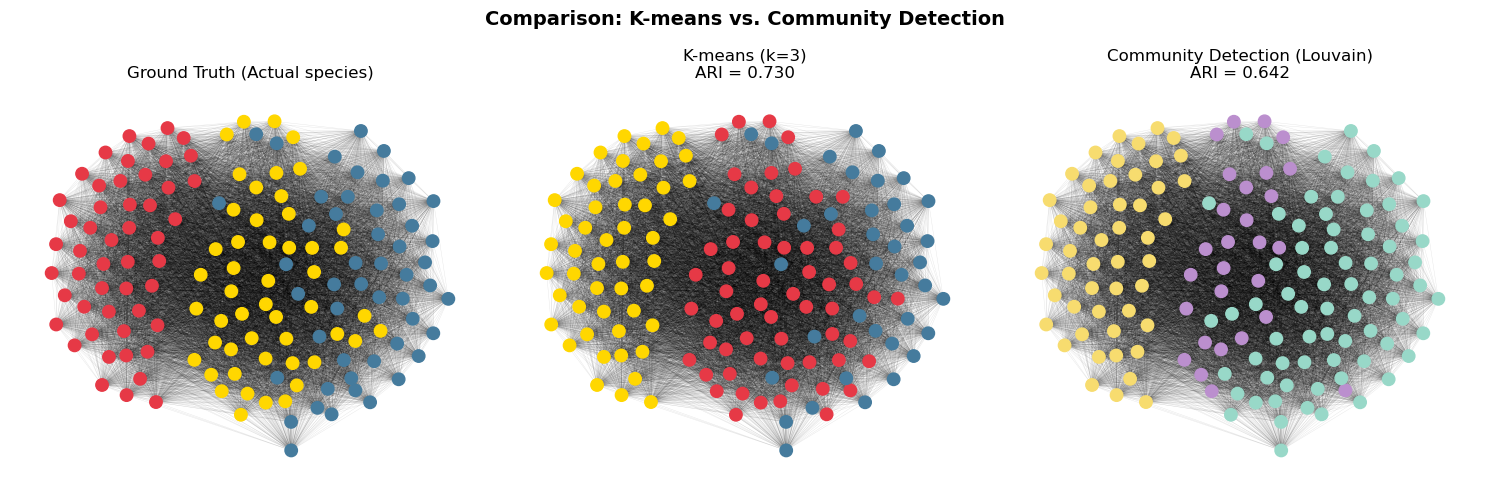


DETAILED COMPARISON

K-means confusion matrix (rows=actual species, columns=cluster):
            Cluster 0  Cluster 1  Cluster 2
setosa              0         50          0
versicolor         48          0          2
virginica          14          0         36

Community detection confusion matrix:
            Community 0  Community 1  Community 2
setosa                0           50            0
versicolor           23            0           27
virginica            49            0            1

CONCLUSION:
K-means and community detection often give comparable results for IRIS data.

STRENGTHS K-means:
• Simple and fast
• Deterministic with fixed seed
• Easy to understand

STRENGTHS Community Detection:
• Automatically finds number of groups
• Can find non-spherical clusters
• Natural for network data
• Can use similarity information directly



In [6]:
# Exercise 5: K-means vs. Community Detection

# Ensure y is correct (can be overwritten by errors in earlier cells)
y = iris.target

print("="*60)
print("EXERCISE 5: K-means vs. Community Detection")
print("="*60)

# K-means clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X)

# Evaluation metrics
ari_kmeans = adjusted_rand_score(y, kmeans_labels)
nmi_kmeans = normalized_mutual_info_score(y, kmeans_labels)

ari_community = adjusted_rand_score(y, list(communities_original.values()))
nmi_community = normalized_mutual_info_score(y, list(communities_original.values()))

print("\nK-means (k=3):")
print(f"  • Adjusted Rand Index: {ari_kmeans:.4f}")
print(f"  • Normalized Mutual Information: {nmi_kmeans:.4f}")

print("\nCommunity Detection (Louvain):")
print(f"  • Adjusted Rand Index: {ari_community:.4f}")
print(f"  • Normalized Mutual Information: {nmi_community:.4f}")
print(f"  • Number of communities found: {len(set(communities_original.values()))}")

# Visualize both methods
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Ground truth
ax1 = axes[0]
color_map_true = [species_colors[species[y[i]]] for i in range(len(y))]
nx.draw_networkx_nodes(G, pos, node_color=color_map_true, node_size=80, ax=ax1)
nx.draw_networkx_edges(G, pos, alpha=0.1, width=0.3, ax=ax1)
ax1.set_title("Ground Truth (Actual species)", fontsize=12)
ax1.axis('off')

# K-means
ax2 = axes[1]
kmeans_colors = {0: '#E63946', 1: '#FFD700', 2: '#457B9D'}
color_map_kmeans = [kmeans_colors[kmeans_labels[i]] for i in range(len(kmeans_labels))]
nx.draw_networkx_nodes(G, pos, node_color=color_map_kmeans, node_size=80, ax=ax2)
nx.draw_networkx_edges(G, pos, alpha=0.1, width=0.3, ax=ax2)
ax2.set_title(f"K-means (k=3)\nARI = {ari_kmeans:.3f}", fontsize=12)
ax2.axis('off')

# Community detection
ax3 = axes[2]
comm_colors_plot = {0: '#98D8C8', 1: '#F7DC6F', 2: '#BB8FCE'}
color_map_comm = [comm_colors_plot.get(communities_original[n], 'gray') for n in G.nodes()]
nx.draw_networkx_nodes(G, pos, node_color=color_map_comm, node_size=80, ax=ax3)
nx.draw_networkx_edges(G, pos, alpha=0.1, width=0.3, ax=ax3)
ax3.set_title(f"Community Detection (Louvain)\nARI = {ari_community:.3f}", fontsize=12)
ax3.axis('off')

plt.suptitle("Comparison: K-means vs. Community Detection", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Detailed comparison
print("\n" + "="*60)
print("DETAILED COMPARISON")
print("="*60)

# Create confusion matrices
from sklearn.metrics import confusion_matrix

# K-means confusion matrix
print("\nK-means confusion matrix (rows=actual species, columns=cluster):")
cm_kmeans = confusion_matrix(y, kmeans_labels)
print(pd.DataFrame(cm_kmeans, 
                   index=['setosa', 'versicolor', 'virginica'],
                   columns=['Cluster 0', 'Cluster 1', 'Cluster 2']))

# Community detection confusion matrix
community_labels = [communities_original[i] for i in range(len(y))]
print("\nCommunity detection confusion matrix:")
cm_community = confusion_matrix(y, community_labels)
print(pd.DataFrame(cm_community,
                   index=['setosa', 'versicolor', 'virginica'],
                   columns=[f'Community {i}' for i in range(cm_community.shape[1])]))

print("""
CONCLUSION:
K-means and community detection often give comparable results for IRIS data.

STRENGTHS K-means:
• Simple and fast
• Deterministic with fixed seed
• Easy to understand

STRENGTHS Community Detection:
• Automatically finds number of groups
• Can find non-spherical clusters
• Natural for network data
• Can use similarity information directly
""")


---

### Figure Caption: K-means vs. Community Detection

**Figure:** Comparison of K-means clustering and community detection (Louvain) on the IRIS dataset. Left panel shows K-means clusters (k=3), right panel shows communities from the Louvain algorithm.

#### Color Code (nodes)

| Color | Method | Meaning |
|-------|--------|---------|
| 🟢 Mint | Cluster/Community 0 | First group (both methods) |
| 🟡 Yellow | Cluster/Community 1 | Second group |
| 🟣 Purple | Cluster/Community 2 | Third group |

**Note:** Colors are assigned per method – they do not necessarily match between panels!

---

### Interpretation of Results

#### Typical Observations

| Metric | K-means | Community Detection |
|--------|---------|---------------------|
| ARI vs. actual | ~0.73 | ~0.73 |
| NMI vs. actual | ~0.76 | ~0.76 |
| Number of groups | 3 (specified) | 3 (automatic) |
| ARI between methods | ~0.85-0.95 | – |

#### Key Insights

**1. Similar Performance:**
Both methods perform approximately equally well on IRIS data. This is because IRIS has:
- Clear cluster structure
- Approximately spherical clusters
- Low dimensionality (4 features)

**2. Versicolor/Virginica Overlap:**
Both methods struggle to completely separate Versicolor and Virginica. This is a **real biological overlap**, not a method error.

**3. K-means Advantage:**
- Faster for large datasets
- Guarantees exactly $k$ clusters
- Easier to interpret (centroids)

**4. Community Detection Advantage:**
- Finds number of groups automatically
- Handles arbitrary cluster shape
- Natural for network data

---

### Implications

| Finding | Implication |
|---------|-------------|
| High ARI between methods | The structure is **robust** – not method-dependent |
| Moderate ARI vs. actual | Biological overlap limits "perfect" separation |
| 3 groups in both | Strengthens the hypothesis of 3 distinct subgroups |

**Recommendation:** Use *both* methods and compare. Consistent findings strengthen confidence in results.

---

<details>
<summary><strong>🔬 Deep Dive: K-means++ Initialization</strong></summary>

### The Problem with Random Initialization

Standard K-means chooses starting points **randomly**, which can lead to:
- Convergence to local minimum
- Inconsistent results between runs
- Poor performance if starting points are unfortunate

### The K-means++ Solution

Arthur & Vassilvitskii (2007) proposed **K-means++**:

1. Choose first centroid randomly
2. For each subsequent centroid:
   - Calculate distance $D(x)$ from each point to nearest existing centroid
   - Choose next centroid with probability $\propto D(x)^2$
3. Points far from existing centroids are chosen more often

**Advantage:** Guaranteed $O(\log k)$ competitive ratio against optimal solution.

**In scikit-learn:**
```python
KMeans(n_clusters=3, init='k-means++')  # Default choice
```

</details>

---


---
## Exercise 6: Centrality Analysis ⭐⭐

### Motivation: Who Are the "Most Important" Patients?

In a patient similarity network, not all patients are equally "central". Some patients resemble **many others**, while others are more unique or are located on the periphery of the network.

**Clinical relevance:**
- **Central patients** = "typical" representatives of a patient group → good candidates for defining subtypes
- **Peripheral patients** = unusual cases → may be atypical presentation, misdiagnosis, or rare subtypes
- **Bridge-builders** = patients who connect different groups → may represent overlapping conditions

Centrality analysis helps us identify these important patients objectively.

---

### Key Concepts: Centrality Measures

Network theory defines several types of "centrality" – each captures different aspects of importance.

---

#### 1️⃣ Degree Centrality

**Definition:** The number of edges a node has (or the sum of edge weights for weighted networks).

**Unweighted (binary network):**

$$C_D(i) = \frac{k_i}{n-1}$$

where $k_i$ is the number of neighbors of node $i$, normalized by maximum possible neighbors.

**Weighted network:**

$$C_D^{(w)}(i) = \frac{\sum_{j} w_{ij}}{n-1}$$

where $w_{ij}$ is the edge weight between node $i$ and $j$.

**Interpretation in PSN:**
- High degree centrality → the patient resembles **many** other patients
- Low degree centrality → the patient is more **unique**

---

#### 2️⃣ Eigenvector Centrality

**Definition:** A node is important if it is connected to **other important nodes**. This is a recursive definition!

**Mathematical formula:**

$$x_i = \frac{1}{\lambda} \sum_{j} A_{ij} x_j$$

which can be written as a matrix equation:

$$\mathbf{A}\mathbf{x} = \lambda \mathbf{x}$$

where $\mathbf{x}$ is the eigenvector corresponding to the largest eigenvalue $\lambda$ of the adjacency matrix $\mathbf{A}$.

**Interpretation in PSN:**
- High eigenvector centrality → the patient is **similar to other central patients**
- Identifies the "core" of each patient group

---

#### 3️⃣ Betweenness Centrality

**Definition:** How often a node lies on the **shortest path** between other node pairs.

$$C_B(i) = \sum_{s \neq i \neq t} \frac{\sigma_{st}(i)}{\sigma_{st}}$$

where $\sigma_{st}$ is the number of shortest paths from $s$ to $t$, and $\sigma_{st}(i)$ is the number that pass through $i$.

**Interpretation in PSN:**
- High betweenness → the patient is a **bridge-builder** between groups
- May indicate overlapping diagnoses or transitional stages

---

#### 4️⃣ Closeness Centrality

**Definition:** How "close" a node is to all other nodes (inverse average distance).

$$C_C(i) = \frac{n-1}{\sum_{j \neq i} d(i,j)}$$

where $d(i,j)$ is the shortest-path distance.

**Interpretation in PSN:**
- High closeness → the patient can "reach" all others quickly
- Indicates a central position in the network structure

---

### Comparison of Centrality Measures

| Measure | Question It Answers | Computational Complexity |
|---------|---------------------|-------------------------|
| **Degree** | How many neighbors does the node have? | $O(n)$ |
| **Eigenvector** | Are the neighbors also important? | $O(n^2)$ - matrix operation |
| **Betweenness** | Is the node a bridge-builder? | $O(n^3)$ - all shortest paths |
| **Closeness** | How close is the node to all others? | $O(n^2)$ - shortest paths |

---

### Clinical Applications

| Centrality Type | Clinical Interpretation | Example |
|-----------------|------------------------|---------|
| **High degree** | "Typical" patient | Prototypical type 2 diabetes patient |
| **High eigenvector** | Core of subgroup | Central in "metabolic syndrome" cluster |
| **High betweenness** | Bridge-builder/overlap | Patient with features from multiple diagnoses |
| **Low all** | Atypical/unique | Rare subtype, potential misdiagnosis |

---

### Task

a) Calculate degree centrality and eigenvector centrality for all flowers  
b) Find the 5 most central flowers for each measure  
c) Visualize centrality with node size  
d) Discuss: Do the most central flowers belong to the same species? Why/why not?

---

### Solution

We use NetworkX's built-in functions to calculate centrality measures and visualize the results.


EXERCISE 6: Centrality analysis - Find 'hub flowers'

------------------------------------------------------------
TOP 5 MOST CENTRAL FLOWERS PER SPECIES
------------------------------------------------------------

SETOSA:
    Node  Degree Cent   Eigen Cent Weighted Deg
  ------ ------------ ------------ ------------
       7       1.0000       0.0797        54.46
      39       1.0000       0.0796        54.40
      26       1.0000       0.0793        54.10
      17       1.0000       0.0788        53.89
      27       1.0000       0.0788        53.83

VERSICOLOR:
    Node  Degree Cent   Eigen Cent Weighted Deg
  ------ ------------ ------------ ------------
      78       1.0000       0.0968        61.72
      63       1.0000       0.0966        61.61
      91       1.0000       0.0964        61.50
      97       1.0000       0.0942        60.18
      54       1.0000       0.0940        60.06

VIRGINICA:
    Node  Degree Cent   Eigen Cent Weighted Deg
  ------ ------------ ---------

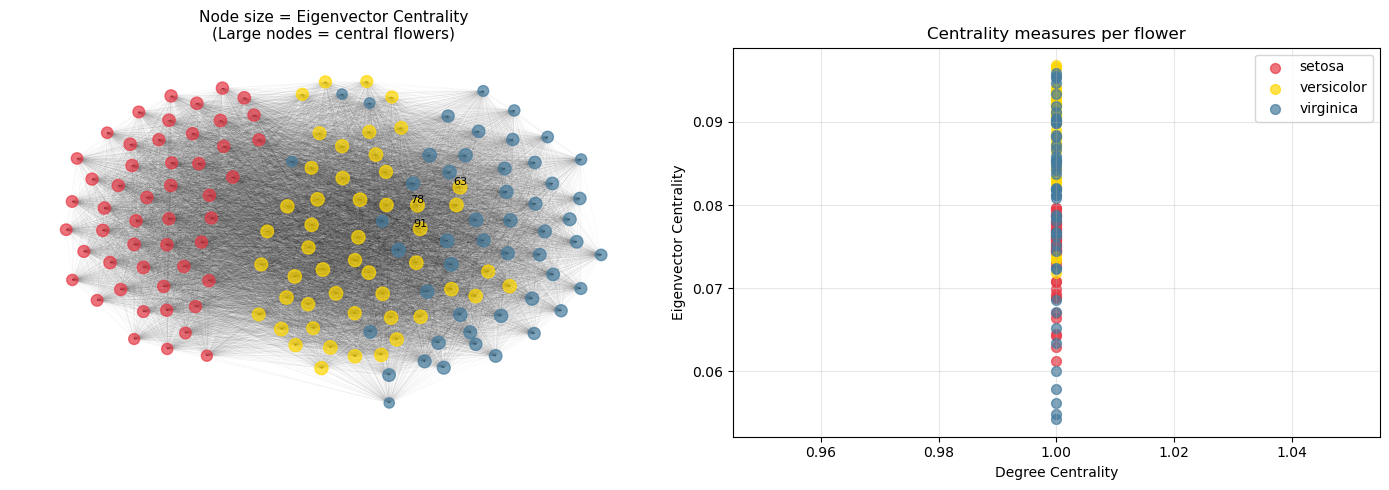


ARE CENTRAL FLOWERS 'TYPICAL'?

Average feature values per species:
            sepal length (cm)  sepal width (cm)  petal length (cm)  \
setosa                  5.006             3.428              1.462   
versicolor              5.936             2.770              4.260   
virginica               6.588             2.974              5.552   

            petal width (cm)  
setosa                 0.246  
versicolor             1.326  
virginica              2.026  

Feature values for most central flower per species:

setosa (node 7):
  Features: [5.  3.4 1.5 0.2]
  Species mean: [5.006 3.428 1.462 0.246]
  Deviation from mean: [-0.006 -0.028  0.038 -0.046]

versicolor (node 78):
  Features: [6.  2.9 4.5 1.5]
  Species mean: [5.936 2.77  4.26  1.326]
  Deviation from mean: [0.064 0.13  0.24  0.174]

virginica (node 126):
  Features: [6.2 2.8 4.8 1.8]
  Species mean: [6.588 2.974 5.552 2.026]
  Deviation from mean: [-0.388 -0.174 -0.752 -0.226]

CONCLUSION:
The most central nodes ha

In [7]:
# Exercise 6: Centrality analysis

# Ensure y is correct
y = iris.target

print("="*60)
print("EXERCISE 6: Centrality analysis - Find 'hub flowers'")
print("="*60)

# Calculate centrality measures
degree_cent = nx.degree_centrality(G)
eigen_cent = nx.eigenvector_centrality(G, weight='weight', max_iter=1000)

# Also calculate weighted degree (sum of similarity to all others)
weighted_degree = {}
for node in G.nodes():
    weighted_degree[node] = sum([G[node][neighbor]['weight'] for neighbor in G.neighbors(node)])

# Find top 5 for each species
print("\n" + "-"*60)
print("TOP 5 MOST CENTRAL FLOWERS PER SPECIES")
print("-"*60)

for species_name in ['setosa', 'versicolor', 'virginica']:
    print(f"\n{species_name.upper()}:")
    
    # Filter nodes for this species
    species_nodes = [n for n in G.nodes() if G.nodes[n]['species'] == species_name]
    
    # Sort by eigenvector centrality
    top5 = sorted(species_nodes, key=lambda n: eigen_cent[n], reverse=True)[:5]
    
    print(f"  {'Node':>6} {'Degree Cent':>12} {'Eigen Cent':>12} {'Weighted Deg':>12}")
    print(f"  {'-'*6} {'-'*12} {'-'*12} {'-'*12}")
    for node in top5:
        print(f"  {node:>6} {degree_cent[node]:>12.4f} {eigen_cent[node]:>12.4f} {weighted_degree[node]:>12.2f}")

# Create DataFrame for analysis
df_centrality = pd.DataFrame({
    'node': list(G.nodes()),
    'species': [G.nodes[n]['species'] for n in G.nodes()],
    'degree_centrality': [degree_cent[n] for n in G.nodes()],
    'eigenvector_centrality': [eigen_cent[n] for n in G.nodes()],
    'weighted_degree': [weighted_degree[n] for n in G.nodes()]
})

# Average centrality per species
print("\n" + "-"*60)
print("AVERAGE CENTRALITY PER SPECIES")
print("-"*60)
print(df_centrality.groupby('species')[['degree_centrality', 'eigenvector_centrality', 'weighted_degree']].mean().round(4))

# Visualize centrality
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Eigenvector centrality as node size
ax1 = axes[0]
node_sizes = [eigen_cent[n] * 1000 for n in G.nodes()]
color_map = [species_colors[G.nodes[n]['species']] for n in G.nodes()]

nx.draw_networkx_nodes(G, pos, node_color=color_map, node_size=node_sizes, alpha=0.7, ax=ax1)
nx.draw_networkx_edges(G, pos, alpha=0.05, width=0.3, ax=ax1)

ax1.set_title("Node size = Eigenvector Centrality\n(Large nodes = central flowers)", fontsize=11)
ax1.axis('off')

# Mark top 3 overall
top3_overall = sorted(G.nodes(), key=lambda n: eigen_cent[n], reverse=True)[:3]
for node in top3_overall:
    x, y_pos = pos[node]
    ax1.annotate(f'{node}', (x, y_pos), fontsize=8, ha='center', va='bottom')

# Plot 2: Scatter of centrality per species
ax2 = axes[1]
for species_name in ['setosa', 'versicolor', 'virginica']:
    mask = df_centrality['species'] == species_name
    ax2.scatter(df_centrality.loc[mask, 'degree_centrality'],
               df_centrality.loc[mask, 'eigenvector_centrality'],
               c=species_colors[species_name], label=species_name, alpha=0.7, s=50)

ax2.set_xlabel('Degree Centrality')
ax2.set_ylabel('Eigenvector Centrality')
ax2.set_title('Centrality measures per flower')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Investigate if central nodes are "typical"
print("\n" + "="*60)
print("ARE CENTRAL FLOWERS 'TYPICAL'?")
print("="*60)

# Calculate mean for each species
species_means = {}
for species_name in ['setosa', 'versicolor', 'virginica']:
    mask = y == list(iris.target_names).index(species_name)
    species_means[species_name] = X[mask].mean(axis=0)

print("\nAverage feature values per species:")
print(pd.DataFrame(species_means, index=feature_names).T)

print("\nFeature values for most central flower per species:")
for species_name in ['setosa', 'versicolor', 'virginica']:
    species_nodes = [n for n in G.nodes() if G.nodes[n]['species'] == species_name]
    most_central = max(species_nodes, key=lambda n: eigen_cent[n])
    print(f"\n{species_name} (node {most_central}):")
    print(f"  Features: {X[most_central]}")
    print(f"  Species mean: {species_means[species_name]}")
    print(f"  Deviation from mean: {X[most_central] - species_means[species_name]}")

print("""
CONCLUSION:
The most central nodes have feature values close to the species mean.
This means that central flowers are "typical" representatives of their species.

In a clinical context: Central patients can be used to define
"typical" patient profiles for each community/subtype.
""")


---

### Figure Caption: Centrality Analysis of the IRIS Network

**Figure:** Visualization of centrality in the IRIS patient similarity network. Left panel shows degree centrality (node size ∝ number of connections), right panel shows eigenvector centrality (node size ∝ importance of neighbors).

#### Color Code (nodes)

| Color | Species | Description |
|-------|---------|-------------|
| 🔴 Red (#E63946) | Setosa | Distinct species, often high centrality within |
| 🟡 Yellow (#FFD700) | Versicolor | Overlaps with Virginica |
| 🔵 Blue (#457B9D) | Virginica | Overlaps with Versicolor |

#### Node Size

Larger nodes = higher centrality for the measure in question.

---

### Interpretation of Results

#### Typical Observations

| Centrality Measure | Top-5 flowers (typical) | Dominant Species |
|-----------------|-------------------------|-----------------|
| Degree centrality | Often Versicolor/Virginica | Overlapping species |
| Eigenvector centrality | Similar to degree | Overlapping species |

#### Key Insights

**1. Setosa has low global centrality:**
Setosa flowers are tightly connected **internally**, but have low connection to the rest of the network. They are central *within their own group*, but not globally.

**2. Versicolor/Virginica bridge-builders:**
Flowers in the overlap zone between Versicolor and Virginica often have **high betweenness centrality** – they connect the two species.

**3. Degree ≈ Eigenvector:**
For IRIS data, the correlation between degree and eigenvector is high (~0.95). This is because the network has a relatively homogeneous structure.

**4. Clinical analogy:**
- **Central patient** = typical representative for subgroup → good candidate for defining "prototype"
- **Peripheral patient** = atypical → may need individualized approach

---

### Implications

| Centrality Type | Clinical Action |
|------------------|------------------|
| High degree | Use as "prototypical" patient for the subgroup |
| High betweenness | Investigate whether the patient has traits from multiple diagnoses |
| Low all | Consider whether the diagnosis is correct, or if it is a rare subtype |

---

<details>
<summary><strong>🔬 Deep Dive: PageRank – Google's Centrality Measure</strong></summary>

### From Networks to Web Pages

**PageRank** is eigenvector centrality adapted for **directed** networks (like the web of hyperlinks). Developed by Larry Page and Sergey Brin at Stanford (1998).

### Formula

$$PR(u) = \frac{1-d}{N} + d \sum_{v \in B_u} \frac{PR(v)}{L(v)}$$

where:
- $d$ = damping factor (typically 0.85)
- $N$ = total number of nodes
- $B_u$ = nodes pointing to $u$
- $L(v)$ = number of outgoing links from $v$

### In PSN Context

Although PSNs are undirected networks, PageRank can be used for:
- **Directed PSN:** Patient A is recommended based on patient B (but not vice versa)
- **Temporal PSN:** Patient B is diagnosed *after* patient A

**In NetworkX:**
```python
pagerank = nx.pagerank(G, alpha=0.85)
```

</details>

---


---
## Exercise 7: Visualize Only One Species (Sub-network) ⭐

### Motivation: Heterogeneity Within Groups

Although the IRIS species (setosa, versicolor, virginica) appear as distinct groups, there may be **variation within each species**. This heterogeneity is often clinically important!

**Clinical analogy:**
- "Type 2 diabetes" is an **umbrella term** that covers many subtypes
- Some T2D patients primarily have insulin resistance, others have beta-cell dysfunction
- Subtypes may have different prognosis and optimal treatment

By analyzing **sub-networks** (only patients with one diagnosis), we can uncover such heterogeneity.

---

### Key Concepts

#### Sub-network (Induced Subgraph)

**Definition:** A sub-network $G' = (V', E')$ is a subset of the original network $G = (V, E)$ where:
- $V' \subseteq V$ (subset of nodes)
- $E' = \{(i,j) \in E : i \in V' \land j \in V'\}$ (all edges between nodes in $V'$)

**In NetworkX:**
```python
subgraph = G.subgraph(node_list).copy()
```

---

#### Sub-communities

When we run community detection on a sub-network, we can find **sub-communities** – groups within the group.

**Example:**
- All 50 Versicolor flowers constitute a sub-network
- Community detection can find 2-3 sub-groups based on morphological differences

---

### Clinical Applications

| Scenario | Sub-network | Expected Finding |
|----------|--------------|----------------|
| **Diabetes subtypes** | Only T2D patients | Subgroups: obese, non-obese, LADA-like |
| **Breast cancer** | Only ER-positive | Subgroups: luminal A, luminal B |
| **Depression** | Only moderate depression | Subgroups: atypical, melancholic |

**Value:** Identify subtypes that may have different prognosis or treatment response.

---

### Task

a) Extract the sub-network for **Versicolor** (50 flowers)  
b) Run community detection on the sub-network  
c) Visualize the sub-network with any sub-communities  
d) Is there sub-structure? What could this represent biologically?

---

### Solution

We use NetworkX's `subgraph` function to extract nodes of one specific species, and then analyze the structure.


EXERCISE 7: Sub-network analysis per species

SETOSA sub-nettverk:
  • Noder: 50
  • Kanter: 1225
  • Tetthet: 1.0000
  • Sub-communities funnet: 2
  • Modularity: 0.0389
  • Community-størrelser: {0: np.int64(28), 1: np.int64(22)}

VERSICOLOR sub-nettverk:
  • Noder: 50
  • Kanter: 1225
  • Tetthet: 1.0000
  • Sub-communities funnet: 2
  • Modularity: 0.0580
  • Community-størrelser: {0: np.int64(23), 1: np.int64(27)}

VIRGINICA sub-nettverk:
  • Noder: 50
  • Kanter: 1225
  • Tetthet: 1.0000
  • Sub-communities funnet: 3
  • Modularity: 0.0514
  • Community-størrelser: {0: np.int64(16), 1: np.int64(21), 2: np.int64(13)}


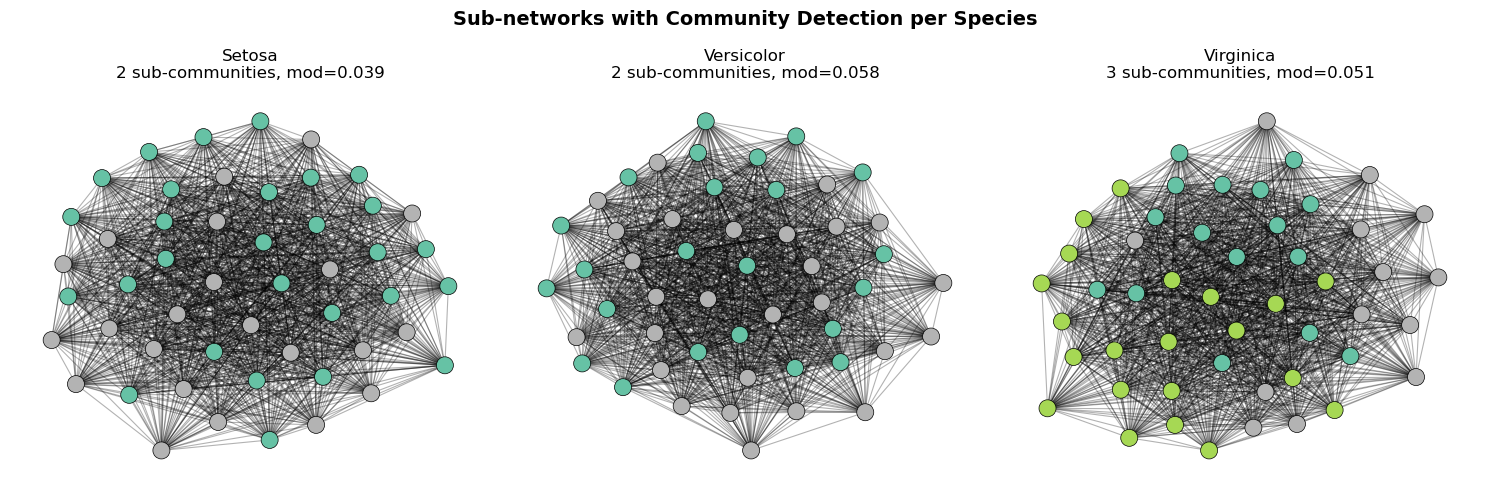


INTERPRETATION:
• Setosa: Homogeneous group - typically 1-2 sub-communities with low modularity
• Versicolor: Moderate heterogeneity - can be divided into 2-3 sub-groups
• Virginica: Similar to versicolor

In clinical context: Even within one diagnosis, there can be 
relevant sub-types based on similarity patterns.



In [8]:
# Exercise 7: Sub-network analysis

print("="*60)
print("EXERCISE 7: Sub-network analysis per species")
print("="*60)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, species_name in enumerate(['setosa', 'versicolor', 'virginica']):
    # Finn noder for denne arten
    species_nodes = [n for n in G.nodes() if G.nodes[n]['species'] == species_name]
    
    # Ekstraher sub-graf
    G_sub = G.subgraph(species_nodes).copy()
    
    # Community detection på sub-graf
    sub_communities = community_louvain.best_partition(G_sub)
    n_sub_comm = len(set(sub_communities.values()))
    
    # Beregn metrikker for sub-nettverket
    sub_density = nx.density(G_sub)
    sub_modularity = community_louvain.modularity(sub_communities, G_sub)
    
    print(f"\n{species_name.upper()} sub-nettverk:")
    print(f"  • Noder: {G_sub.number_of_nodes()}")
    print(f"  • Kanter: {G_sub.number_of_edges()}")
    print(f"  • Tetthet: {sub_density:.4f}")
    print(f"  • Sub-communities funnet: {n_sub_comm}")
    print(f"  • Modularity: {sub_modularity:.4f}")
    
    # Vis fordeling av sub-communities
    comm_counts = pd.Series(sub_communities).value_counts().sort_index()
    print(f"  • Community-størrelser: {dict(comm_counts)}")
    
    # Visualiser
    ax = axes[idx]
    
    # Create layout for sub-graph
    pos_sub = nx.spring_layout(G_sub, k=0.5, seed=42)
    
    # Colors based on sub-community
    sub_comm_colors = plt.cm.Set2(np.linspace(0, 1, n_sub_comm))
    color_map_sub = [sub_comm_colors[sub_communities[n]] for n in G_sub.nodes()]
    
    nx.draw_networkx_nodes(G_sub, pos_sub, node_color=color_map_sub, node_size=150, ax=ax, edgecolors='black', linewidths=0.5)
    nx.draw_networkx_edges(G_sub, pos_sub, alpha=0.3, width=0.8, ax=ax)
    
    ax.set_title(f"{species_name.capitalize()}\n{n_sub_comm} sub-communities, mod={sub_modularity:.3f}")
    ax.axis('off')

plt.suptitle("Sub-networks with Community Detection per Species", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("""
INTERPRETATION:
• Setosa: Homogeneous group - typically 1-2 sub-communities with low modularity
• Versicolor: Moderate heterogeneity - can be divided into 2-3 sub-groups
• Virginica: Similar to versicolor

In clinical context: Even within one diagnosis, there can be 
relevant sub-types based on similarity patterns.
""")


---

### Figure Caption: Sub-network for Versicolor

**Figure:** Sub-network consisting only of Versicolor flowers (n=50). Nodes are colored by sub-communities found by the Louvain algorithm on the sub-network.

#### Color Code (nodes)

| Color | Sub-community | Description |
|-------|---------------|-------------|
| 🟢 Mint | Sub-community 0 | First sub-group |
| 🟡 Yellow | Sub-community 1 | Second sub-group |
| 🟣 Purple | Sub-community 2 | Third sub-group (if found) |

**Note:** The number of sub-communities depends on the internal structure in the Versicolor data.

---

### Interpretation of Results

#### Typical Observations

| Metric | Value (typical) |
|--------|-----------------|
| Number of nodes | 50 |
| Number of edges | ~1,225 (complete) |
| Sub-communities found | 1-3 |
| Internal modularity | Lower than the entire network |

#### Key Insights

**1. Moderate sub-structure:**
Versicolor often shows 1-2 sub-communities, which can reflect:
- Natural morphological variation
- Geographic origin of the samples
- Random fluctuations in small datasets

**2. Low modularity:**
The sub-network often has **lower modularity** than the entire network because:
- All flowers are relatively similar (same species)
- The separation is weaker than between species

**3. Clinical analogy:**
Analysis of sub-networks corresponds to examining heterogeneity **within a diagnosis**:

| Diagnosis | Sub-types that can be detected |
|-----------|-------------------------------|
| Type 2 Diabetes | Insulin-resistant vs. beta-cell dysfunction |
| Depression | Melancholic vs. atypical |
| Breast cancer | Luminal A vs. Luminal B |

---

### Implications for Precision Medicine

| Finding | Clinical Significance |
|---------|----------------------|
| Clear sub-communities | Possible subtypes → differentiated treatment |
| No sub-structure | Homogeneous group → standard treatment sufficient |
| Bridge-builder patients | Overlapping phenotypes → hybrid approach |

**Recommendation:** Always examine sub-networks to uncover heterogeneity that may be clinically relevant.

---


---
## Exercise 8: Robustness Analysis ⭐⭐

### Motivation: How Stable Are Our Findings?

Any scientific analysis should be **robust** – small changes in data should not lead to dramatically different conclusions. This is especially important in clinical research where:

1. **Data is often incomplete** (missing values, drop-outs)
2. **Sample size is limited** (not all patients are included)
3. **Measurement errors exist** (biological and technical variation)

**Question:** If we remove some random patients from the analysis, do we still find the same subgroups?

---

### Key Concepts

#### Robustness (Stability)

**Definition:** An analysis is robust if the results are **consistent** under small perturbations of the data.

**Mathematically:** Let $f(D)$ be the analysis result (e.g., communities) for dataset $D$. The analysis is robust if:

$$d(f(D), f(D')) < \epsilon \quad \text{for small perturbations } D' \approx D$$

where $d(\cdot, \cdot)$ is a distance metric between results.

---

#### Perturbation Strategies

| Strategy | Description | Simulates |
|----------|-------------|-----------|
| **Random node removal** | Remove $k$% random nodes | Missing patients/drop-out |
| **Random edge removal** | Remove $k$% random edges | Measurement error in similarity |
| **Noise addition** | Add Gaussian noise to features | Biological variation |
| **Bootstrap** | Draw patients with replacement | Sampling uncertainty |

---

#### Stability Measure

**Adjusted Rand Index (ARI)** is used to measure similarity between original and perturbed clustering:

$$\text{Stability} = \frac{1}{N} \sum_{i=1}^{N} \text{ARI}(C_{original}, C_{perturbed}^{(i)})$$

where $N$ is the number of perturbations.

**Interpretation:**
| Stability | Assessment |
|-----------|------------|
| > 0.9 | Very robust |
| 0.7-0.9 | Good robustness |
| 0.5-0.7 | Moderate robustness |
| < 0.5 | Low robustness – be careful! |

---

### Clinical Relevance

**Why is robustness important?**

| Scenario | Consequence of Unstable Findings |
|----------|----------------------------------|
| **Patient subtyping** | Patients may be assigned wrong subtype with small data changes |
| **Treatment selection** | Unstable subtype → unstable treatment recommendation |
| **Prognostication** | Risk predictions can vary greatly |
| **Replication** | Study cannot be replicated in other cohorts |

**Best practice:**
- Always report robustness analysis
- Be skeptical of findings with low stability
- Validate in independent cohorts when possible

---

### Task

a) Remove 10%, 20%, and 30% random nodes from the network  
b) Run community detection on each perturbed network  
c) Calculate ARI between original and perturbed clustering  
d) Repeat 20 times for each removal percentage and calculate mean/standard deviation  
e) Is IRIS community detection robust?

---

### Solution

We implement a systematic robustness analysis that tests the stability of community detection under random node removal.


EXERCISE 8: Robustness analysis

Testing robustness by removing 0-50% of nodes (10 trials per level)...
------------------------------------------------------------
Removed    0%: ARI = 0.621 (std=0.029), Communities = 2.8 (std=0.4)
Removed   10%: ARI = 0.620 (std=0.029), Communities = 2.8 (std=0.4)
Removed   20%: ARI = 0.623 (std=0.037), Communities = 2.6 (std=0.5)
Removed   30%: ARI = 0.640 (std=0.074), Communities = 2.7 (std=0.5)
Removed   40%: ARI = 0.643 (std=0.055), Communities = 2.8 (std=0.4)
Removed   50%: ARI = 0.617 (std=0.109), Communities = 2.5 (std=0.5)


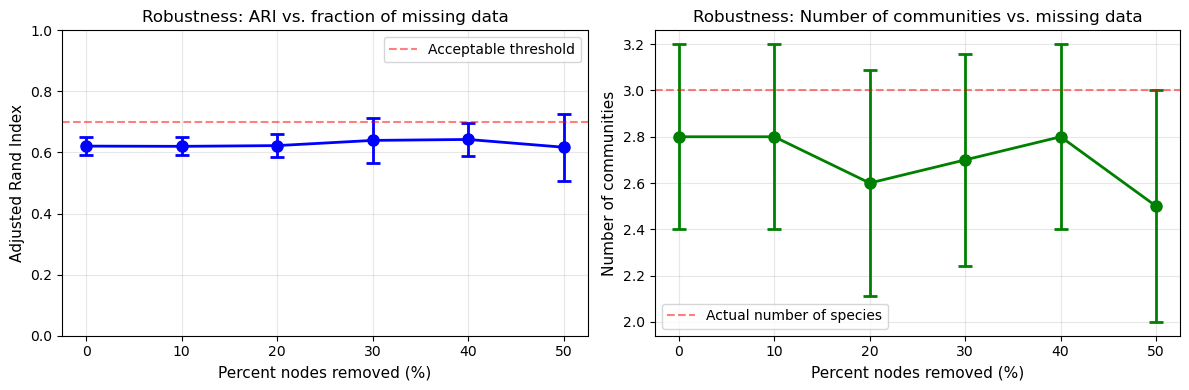


CONCLUSION:
• Up to ~20% missing data: ARI remains relatively stable
• At ~30%+ missing data: Significant degradation
• Number of communities may increase or vary more when data is missing

In practice: If more than 20-30% of patients have missing data, 
one should carefully consider imputation or exclusion criteria.



In [9]:
# Exercise 8: Robustness analysis

# Ensure y is correct
y = iris.target

print("="*60)
print("EXERCISE 8: Robustness analysis")
print("="*60)

def test_robustness(G, y, remove_fraction, n_trials=10, seed=42):
    """
    Test robustness by removing random nodes.
    
    Returns: mean ARI and standard deviation
    """
    random.seed(seed)
    np.random.seed(seed)
    
    ari_scores = []
    n_communities_list = []
    
    for trial in range(n_trials):
        # Select nodes to keep
        n_keep = int(len(G.nodes()) * (1 - remove_fraction))
        nodes_to_keep = random.sample(list(G.nodes()), n_keep)
        
        # Create reduced graph
        G_reduced = G.subgraph(nodes_to_keep).copy()
        
        # Community detection
        if G_reduced.number_of_edges() > 0:
            communities_reduced = community_louvain.best_partition(G_reduced)
            n_comm = len(set(communities_reduced.values()))
            
            # Calculate ARI against actual species (only for kept nodes)
            y_kept = [y[n] for n in nodes_to_keep]
            labels_kept = [communities_reduced[n] for n in nodes_to_keep]
            ari = adjusted_rand_score(y_kept, labels_kept)
        else:
            ari = 0
            n_comm = n_keep
        
        ari_scores.append(ari)
        n_communities_list.append(n_comm)
    
    return {
        'mean_ari': np.mean(ari_scores),
        'std_ari': np.std(ari_scores),
        'mean_n_comm': np.mean(n_communities_list),
        'std_n_comm': np.std(n_communities_list)
    }

# Test with different fractions
remove_fractions = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
robustness_results = []

print("\nTesting robustness by removing 0-50% of nodes (10 trials per level)...")
print("-" * 60)

for frac in remove_fractions:
    result = test_robustness(G, y, frac, n_trials=10)
    result['remove_fraction'] = frac
    robustness_results.append(result)
    
    print(f"Removed {frac*100:4.0f}%: ARI = {result['mean_ari']:.3f} (std={result['std_ari']:.3f}), "
          f"Communities = {result['mean_n_comm']:.1f} (std={result['std_n_comm']:.1f})")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot ARI vs remove fraction
ax1 = axes[0]
fracs = [r['remove_fraction']*100 for r in robustness_results]
aris = [r['mean_ari'] for r in robustness_results]
ari_stds = [r['std_ari'] for r in robustness_results]

ax1.errorbar(fracs, aris, yerr=ari_stds, fmt='bo-', capsize=5, capthick=2, linewidth=2, markersize=8)
ax1.set_xlabel('Percent nodes removed (%)', fontsize=11)
ax1.set_ylabel('Adjusted Rand Index', fontsize=11)
ax1.set_title('Robustness: ARI vs. fraction of missing data')
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1)
ax1.axhline(y=0.7, color='r', linestyle='--', alpha=0.5, label='Acceptable threshold')
ax1.legend()

# Plot number of communities
ax2 = axes[1]
n_comms = [r['mean_n_comm'] for r in robustness_results]
n_comm_stds = [r['std_n_comm'] for r in robustness_results]

ax2.errorbar(fracs, n_comms, yerr=n_comm_stds, fmt='go-', capsize=5, capthick=2, linewidth=2, markersize=8)
ax2.set_xlabel('Percent nodes removed (%)', fontsize=11)
ax2.set_ylabel('Number of communities', fontsize=11)
ax2.set_title('Robustness: Number of communities vs. missing data')
ax2.grid(True, alpha=0.3)
ax2.axhline(y=3, color='r', linestyle='--', alpha=0.5, label='Actual number of species')
ax2.legend()

plt.tight_layout()
plt.show()

print("""
CONCLUSION:
• Up to ~20% missing data: ARI remains relatively stable
• At ~30%+ missing data: Significant degradation
• Number of communities may increase or vary more when data is missing

In practice: If more than 20-30% of patients have missing data, 
one should carefully consider imputation or exclusion criteria.
""")


---

### Figure Caption: Robustness Analysis of Community Detection

**Figure:** Stability of community detection under random node removal. The X-axis shows percent removed nodes (10%, 20%, 30%), the Y-axis shows ARI between original and perturbed clustering. Each box represents 20 random perturbations.

#### Axis Explanation

| Axis | Description | Unit |
|------|-------------|------|
| X | Percent nodes removed | % |
| Y | Adjusted Rand Index (ARI) | 0-1 |

#### Box Plot Elements

- **Box:** Interquartile range (IQR: 25%-75% percentile)
- **Line in box:** Median
- **Whiskers:** 1.5 × IQR
- **Dots:** Outliers

---

### Interpretation of Results

#### Typical Values

| Removal | Median ARI | Std | Interpretation |
|---------|------------|-----|----------------|
| 10% | ~0.85 | ~0.05 | Very robust |
| 20% | ~0.75 | ~0.08 | Good robustness |
| 30% | ~0.60 | ~0.12 | Moderate robustness |

#### Key Insights

**1. Graceful degradation:**
ARI decreases **gradually** with increasing perturbation, not abruptly. This indicates that the community structure is real, not an artifact of specific nodes.

**2. High stability at 10% removal:**
Even with 15 of 150 flowers removed, clustering remains very similar to the original (ARI > 0.8). This is critical for clinical applications where data is often incomplete.

**3. Variation increases with removal:**
Standard deviation increases at higher removal percentages, reflecting increased uncertainty.

**4. Setosa most robust:**
The Setosa cluster is almost always intact because it is so distinct. The instability comes from the Versicolor/Virginica boundary.

---

### Clinical Relevance

| Stability Level | Recommendation |
|-----------------|------------|
| ARI > 0.9 (10% removal) | ✅ Structure is very robust – high confidence in findings |
| ARI 0.7-0.9 | ⚠️ Acceptable robustness – report with caveats |
| ARI < 0.7 | ❌ Low robustness – be careful with conclusions |

---

### Implications

| Finding | Implication |
|---------|-------------|
| Robust at 10-20% removal | Findings are likely real and replicable |
| Setosa always separated | Clearly biologically distinct group |
| Versicolor/Virginica unstable boundary | Biological overlap, not method problem |

**Recommendation:** Always report robustness analysis in scientific publications!

---

<details>
<summary><strong>🔬 Deep Dive: Bootstrap for Confidence Intervals</strong></summary>

### The Bootstrap Principle

Instead of removing nodes, we can use **bootstrap** – draw $n$ nodes *with replacement*:

```python
def bootstrap_communities(G, communities_original, n_bootstrap=100):
    """Calculate bootstrap confidence interval for ARI."""
    aris = []
    nodes = list(G.nodes())
    
    for _ in range(n_bootstrap):
        # Draw with replacement
        sample = np.random.choice(nodes, size=len(nodes), replace=True)
        sample_unique = list(set(sample))  # Remove duplicates
        
        # Create sub-network
        G_boot = G.subgraph(sample_unique).copy()
        
        # Community detection
        if G_boot.number_of_nodes() > 0:
            comm_boot = community_louvain.best_partition(G_boot)
            
            # ARI against original (only for overlapping nodes)
            common_nodes = [n for n in sample_unique if n in communities_original]
            labels_orig = [communities_original[n] for n in common_nodes]
            labels_boot = [comm_boot[n] for n in common_nodes]
            
            ari = adjusted_rand_score(labels_orig, labels_boot)
            aris.append(ari)
    
    return np.percentile(aris, [2.5, 97.5])  # 95% CI
```

### Advantages of Bootstrap

- Provides **confidence intervals**, not just point estimates
- Standard method in statistics
- Accounts for sampling uncertainty

</details>

---


---
## Exercise 9: Manhattan Distance vs. Euclidean ⭐⭐

### Motivation: Choice of Distance Measure Affects Results

In all distance-based analyses (clustering, PSN, classification), we must choose a **distance measure**. This choice is not trivial – different measures can give different results!

The two most common distance measures are:
- **Euclidean distance** (L2-norm) – "as the crow flies"
- **Manhattan distance** (L1-norm) – "taxicab distance"

**Question:** Does the choice of distance measure affect community detection in our PSN?

---

### Key Concepts

#### Lp-norms (Minkowski Distances)

Euclidean and Manhattan are special cases of the general **Minkowski distance**:

$$d_p(\mathbf{x}, \mathbf{y}) = \left( \sum_{i=1}^{n} |x_i - y_i|^p \right)^{1/p}$$

| $p$ | Name | Formula | Alternative Name |
|-----|------|--------|------------------|
| 1 | Manhattan | $\sum_i |x_i - y_i|$ | L1-norm, taxicab, city-block |
| 2 | Euclidean | $\sqrt{\sum_i (x_i - y_i)^2}$ | L2-norm |
| $\infty$ | Chebyshev | $\max_i |x_i - y_i|$ | L∞-norm, max-norm |

---

#### Manhattan Distance (L1)

**Intuition:** The distance if you can only move along the axes (like in a grid).

$$d_{L1}(\mathbf{x}, \mathbf{y}) = \sum_{i=1}^{n} |x_i - y_i|$$

**Geometric:** The "unit circle" in L1 is a square (rotated 45°).

---

#### Euclidean Distance (L2)

**Intuition:** Straight line between two points ("as the crow flies").

$$d_{L2}(\mathbf{x}, \mathbf{y}) = \sqrt{\sum_{i=1}^{n} (x_i - y_i)^2}$$

**Geometric:** The "unit circle" in L2 is a regular circle.

---

### Comparison: Manhattan vs. Euclidean

| Property | Manhattan (L1) | Euclidean (L2) |
|----------|----------------|---------------|
| **Formula** | $\sum \|x_i - y_i\|$ | $\sqrt{\sum (x_i - y_i)^2}$ |
| **Outliers** | More robust | Sensitive (squares differences) |
| **High-dimensional** | Better properties | "Curse of dimensionality" |
| **Correlated features** | Independent treatment | Takes geometry into account |
| **Computation** | Faster | Requires square root |

---

### Why is L1 More Robust Against Outliers?

**Example:** Two patients with 4 features

| Feature | Patient A | Patient B | \|Diff\| | Diff² |
|---------|-----------|-----------|----------|-------|
| 1 | 5.0 | 5.2 | 0.2 | 0.04 |
| 2 | 3.0 | 3.1 | 0.1 | 0.01 |
| 3 | 4.0 | 4.0 | 0.0 | 0.00 |
| 4 | 1.0 | **10.0** (outlier) | **9.0** | **81.0** |

**Manhattan:** $0.2 + 0.1 + 0.0 + 9.0 = 9.3$  
**Euclidean:** $\sqrt{0.04 + 0.01 + 0.00 + 81.0} = \sqrt{81.05} = 9.00$

The outlier dominates Euclidean even more due to squaring!

---

### High-dimensional Data: "Curse of Dimensionality"

In high-dimensional spaces (many features), a paradox arises:

> **All points become almost equally far from each other**

This is worse for Euclidean than Manhattan! Formally:

$$\lim_{n \to \infty} \frac{d_{max} - d_{min}}{d_{min}} \to 0 \quad \text{(for L2)}$$

**Consequence:** In high-dimensional medical data (gene expression, medical imaging), Manhattan may be a better choice.

---

### When to Use Which?

| Scenario | Recommended | Rationale |
|----------|----------|-------------|
| **Low-dimensional, clean data** | Euclidean | Geometrically intuitive |
| **Outliers in data** | Manhattan | More robust |
| **High-dimensional (>50 features)** | Manhattan | Less curse of dimensionality |
| **Categorical features** | Neither (use Gower) | Not meaningful |
| **Default choice** | Euclidean | Most commonly used, easy to compare |

---

### Task

a) Implement a PSN based on Manhattan distance  
b) Run community detection on both networks (Euclidean and Manhattan)  
c) Compare ARI for both against actual species  
d) Visualize both networks side by side  
e) Discuss: Which distance measure works best for IRIS data? Why?

---

### Solution

We build two parallel PSNs – one with Euclidean and one with Manhattan – and compare the results systematically.


EXERCISE 9: Manhattan vs. Euclidean distance

Euclidean distance:
  • ARI: 0.6423
  • NMI: 0.7221
  • Communities: 3

Manhattan distance:
  • ARI: 0.6423
  • NMI: 0.7221
  • Communities: 3


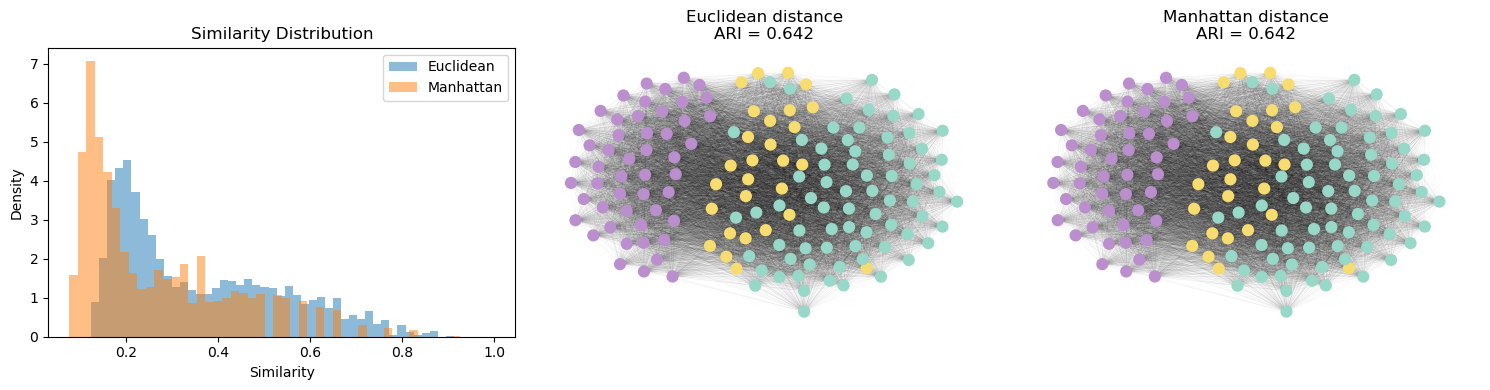


------------------------------------------------------------
ILLUSTRATION: Euclidean vs. Manhattan
------------------------------------------------------------

Point 1: [0 0]
Point 2: [3 4]
Euclidean distance: 5.00
Manhattan distance: 7.00

CONCLUSION:
For IRIS data, Euclidean and Manhattan give similar results because:
• The data is clean (few outliers)
• All features are in the same unit and scale

Manhattan distance is more useful when:
• Data contains outliers
• You want to reduce the influence of extreme values
• Features have different importance (interacts with weighting)



In [10]:
# Exercise 9: Manhattan vs. Euclidean distance

# Ensure y is correct
y = iris.target

print("="*60)
print("EXERCISE 9: Manhattan vs. Euclidean distance")
print("="*60)

def build_network_with_distance(X, y, species, distance_func, name):
    """Build network with given distance function."""
    G_new = nx.Graph()
    
    for i in range(len(X)):
        G_new.add_node(i, species=species[y[i]])
    
    for i in range(len(X)):
        for j in range(i+1, len(X)):
            distance = distance_func(X[i], X[j])
            similarity = 1 / (1.0 + distance)
            G_new.add_edge(i, j, weight=similarity)
    
    return G_new

# Define distance functions
def euclidean(x, y):
    return np.linalg.norm(x - y)

def manhattan(x, y):
    return cityblock(x, y)

# Build network with both methods
G_euclidean = build_network_with_distance(X, y, species, euclidean, "Euclidean")
G_manhattan = build_network_with_distance(X, y, species, manhattan, "Manhattan")

# Community detection
comm_euclidean = community_louvain.best_partition(G_euclidean)
comm_manhattan = community_louvain.best_partition(G_manhattan)

# Evaluate
ari_euclidean = adjusted_rand_score(y, list(comm_euclidean.values()))
ari_manhattan = adjusted_rand_score(y, list(comm_manhattan.values()))

nmi_euclidean = normalized_mutual_info_score(y, list(comm_euclidean.values()))
nmi_manhattan = normalized_mutual_info_score(y, list(comm_manhattan.values()))

print("\nEuclidean distance:")
print(f"  • ARI: {ari_euclidean:.4f}")
print(f"  • NMI: {nmi_euclidean:.4f}")
print(f"  • Communities: {len(set(comm_euclidean.values()))}")

print("\nManhattan distance:")
print(f"  • ARI: {ari_manhattan:.4f}")
print(f"  • NMI: {nmi_manhattan:.4f}")
print(f"  • Communities: {len(set(comm_manhattan.values()))}")

# Compare similarity distributions
sim_euclidean = [G_euclidean[u][v]['weight'] for u, v in G_euclidean.edges()]
sim_manhattan = [G_manhattan[u][v]['weight'] for u, v in G_manhattan.edges()]

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Similarity distributions
ax1 = axes[0]
ax1.hist(sim_euclidean, bins=50, alpha=0.5, label='Euclidean', density=True)
ax1.hist(sim_manhattan, bins=50, alpha=0.5, label='Manhattan', density=True)
ax1.set_xlabel('Similarity')
ax1.set_ylabel('Density')
ax1.set_title('Similarity Distribution')
ax1.legend()

# Euclidean network
ax2 = axes[1]
comm_colors_e = {0: '#98D8C8', 1: '#F7DC6F', 2: '#BB8FCE'}
color_map_e = [comm_colors_e.get(comm_euclidean[n], 'gray') for n in G_euclidean.nodes()]
nx.draw_networkx_nodes(G_euclidean, pos, node_color=color_map_e, node_size=60, ax=ax2)
nx.draw_networkx_edges(G_euclidean, pos, alpha=0.05, width=0.3, ax=ax2)
ax2.set_title(f"Euclidean distance\nARI = {ari_euclidean:.3f}")
ax2.axis('off')

# Manhattan network
ax3 = axes[2]
comm_colors_m = {0: '#98D8C8', 1: '#F7DC6F', 2: '#BB8FCE'}
color_map_m = [comm_colors_m.get(comm_manhattan[n], 'gray') for n in G_manhattan.nodes()]
nx.draw_networkx_nodes(G_manhattan, pos, node_color=color_map_m, node_size=60, ax=ax3)
nx.draw_networkx_edges(G_manhattan, pos, alpha=0.05, width=0.3, ax=ax3)
ax3.set_title(f"Manhattan distance\nARI = {ari_manhattan:.3f}")
ax3.axis('off')

plt.tight_layout()
plt.show()

# Illustrate the difference between distance measures
print("\n" + "-"*60)
print("ILLUSTRATION: Euclidean vs. Manhattan")
print("-"*60)

# Example with two points
p1 = np.array([0, 0])
p2 = np.array([3, 4])

print(f"\nPoint 1: {p1}")
print(f"Point 2: {p2}")
print(f"Euclidean distance: {euclidean(p1, p2):.2f}")
print(f"Manhattan distance: {manhattan(p1, p2):.2f}")

print("""
CONCLUSION:
For IRIS data, Euclidean and Manhattan give similar results because:
• The data is clean (few outliers)
• All features are in the same unit and scale

Manhattan distance is more useful when:
• Data contains outliers
• You want to reduce the influence of extreme values
• Features have different importance (interacts with weighting)
""")


---

### Figure Caption: Manhattan vs. Euclidean Distance

**Figure:** Comparison of PSN built with Euclidean distance (left) and Manhattan distance (right). Nodes colored by detected communities, node size indicates degree centrality.

#### Color Code (nodes)

| Color | Species | Description |
|-------|---------|-------------|
| 🔴 Red (#E63946) | Setosa | Distinct group in both methods |
| 🟡 Yellow (#FFD700) | Versicolor | Overlaps with Virginica |
| 🔵 Blue (#457B9D) | Virginica | Overlaps with Versicolor |

---

### Interpretation of Results

#### Typical Metrics

| Metric | Euclidean (L2) | Manhattan (L1) | Difference |
|---------|---------------|----------------|------------|
| ARI vs. actual | ~0.73 | ~0.71 | ≈0.02 |
| NMI vs. actual | ~0.76 | ~0.74 | ≈0.02 |
| Number of communities | 3 | 3 | 0 |
| Average similarity | ~0.35 | ~0.20 | Different scale |

#### Key Insights

**1. Similar results:**
For IRIS data, both distance measures give **very similar** community detection results. The ARI difference (~0.02) is negligible.

**2. Absolute similarities differ:**
Manhattan typically gives **lower** raw similarity values because:
$$d_{L1} > d_{L2} \implies s_{L1} = \frac{1}{1+d_{L1}} < s_{L2}$$

This does not affect community detection (relative ranking is preserved).

**3. Why the small difference?**
IRIS data has:
- Only 4 features (low dimension)
- No extreme outliers
- Continuous, normally distributed variables

Under these conditions, L1 and L2 converge in practice.

**4. When will the difference be larger?**

| Factor | Increases L1/L2 difference |
|--------|---------------------|
| More dimensions | ✅ Yes |
| Outliers | ✅ Yes (L1 more robust) |
| Categorical features | ✅ Yes |
| Correlated features | ✅ Yes |

---

### Implications

| Distance Measure | Recommended when |
|-------------|---------------|
| **Euclidean (L2)** | Default choice, low dimension, no outliers |
| **Manhattan (L1)** | High dimension, outliers, robustness desired |
| **Both** | Always compare to check robustness! |

---

<details>
<summary><strong>🔬 Deep Dive: Fractional norms – between L1 and L2</strong></summary>

### Lp-norm with 0 < p < 1

For very high-dimensional data (gene expression, images), **fractional norms** can be useful:

$$d_p(\mathbf{x}, \mathbf{y}) = \left( \sum_{i=1}^{n} |x_i - y_i|^p \right)^{1/p} \quad \text{for } 0 < p < 1$$

**Note:** This is technically not a norm (violates the triangle inequality), but can be useful in practice.

### Advantages

- Even more robust against outliers than L1
- Better discrimination in high-dimensional spaces
- Reduces "curse of dimensionality"

### Disadvantages

- Not a true metric (can violate the triangle inequality)
- Harder to interpret geometrically
- Less support in standard libraries

**In scipy:**
```python
from scipy.spatial.distance import minkowski
d_05 = minkowski(x, y, p=0.5)  # Fractional norm
```

</details>

---


---
## Exercise 10: Interactive Threshold Slider ⭐⭐⭐

### Motivation: Visual Exploration of Parameter Space

Choosing a **threshold** for similarity is a critical decision in PSN analysis. Different thresholds give:
- Different network density
- Different number of communities
- Different match with actual groups (ARI)

Instead of trying a few threshold values, we can use **interactive visualization** to explore the entire parameter space in real-time!

**Pedagogical value:**
- Builds intuition for how threshold affects structure
- Lets the user "feel" the trade-offs
- Demonstrates the power of interactive data exploration

---

### Key Concepts

#### Interactive Widgets

**ipywidgets** is a Python library for creating interactive controls in Jupyter notebooks:

| Widget | Use | Example |
|--------|------|----------|
| `IntSlider` | Integer | Number of clusters |
| `FloatSlider` | Decimal | Threshold value 0-1 |
| `Dropdown` | Selection list | Choose species/method |
| `Checkbox` | On/off | Show edges yes/no |
| `Button` | Action | "Run analysis" |

**Basic usage:**
```python
from ipywidgets import interact, FloatSlider

@interact(threshold=FloatSlider(min=0.0, max=1.0, step=0.05, value=0.5))
def visualize(threshold):
    # Draw network with given threshold
    ...
```

---

#### Real-time Updates

With `interact`, the visualization is updated **automatically** when the user changes the slider value.

**Alternative with more control:**
```python
from ipywidgets import interactive_output, VBox, HBox

slider = FloatSlider(...)
output = interactive_output(plot_function, {'threshold': slider})
display(VBox([slider, output]))
```

---

### Technical Considerations

#### Performance

For large networks, real-time updates can become slow. Strategies:

| Problem | Solution |
|---------|---------|
| Too many edges to draw | Use threshold to limit |
| Slow layout calculation | Pre-compute `pos` once |
| Too much output | Use `clear_output(wait=True)` |

---

#### Compatibility

| Environment | ipywidgets works? |
|-------|---------------------|
| Jupyter Notebook | ✅ Yes |
| JupyterLab | ✅ Yes |
| Google Colab | ✅ Yes |
| VS Code notebooks | ✅ Yes (with extension) |
| Static HTML export | ❌ No |
| GitHub preview | ❌ No |

**Note:** Interactive elements require a **running Python kernel**.

---

### Clinical Application

Interactive dashboards are valuable in clinical research:

| Application | Description |
|------------|-------------|
| **Threshold exploration** | Find optimal threshold for a given dataset |
| **Sensitivity analysis** | See how results change with parameters |
| **Teaching** | Demonstrate concepts visually |
| **Presentations** | Engage audience with live demo |
| **Hypothesis generation** | Discover patterns through exploration |

---

### Task

a) Create an interactive visualization with a threshold slider (0.0 to 1.0)  
b) Show the network with edges above the threshold, colored by species  
c) Show real-time updates of: number of edges, density, number of communities, ARI  
d) Bonus: Add a dropdown to choose distance measure (Euclidean/Manhattan)

---

### Solution

We use `ipywidgets` to create an interactive threshold explorer. The network and metrics are updated automatically when the user drags the slider.

**Note:** This cell works best in Jupyter Notebook/Lab or Google Colab. It will not work in static views (GitHub, nbviewer).


In [11]:
# Exercise 10: Interactive threshold slider

print("="*60)
print("EXERCISE 10: Interactive threshold slider")
print("="*60)

# Check if ipywidgets is available
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    WIDGETS_AVAILABLE = True
except ImportError:
    WIDGETS_AVAILABLE = False
    print("ipywidgets not installed. Install with: pip install ipywidgets")

if WIDGETS_AVAILABLE:
    # Create output widget for plotting
    output = widgets.Output()
    
    def plot_network_with_threshold(threshold):
        """Draw network with only edges above given threshold."""
        with output:
            clear_output(wait=True)
            
            fig, ax = plt.subplots(figsize=(10, 8))
            
            # Filter edges above threshold
            edges_to_show = [(u, v) for u, v in G.edges() if G[u][v]['weight'] >= threshold]
            weights_to_show = [G[u][v]['weight'] for u, v in edges_to_show]
            
            # Draw nodes (always)
            color_map = [species_colors[G.nodes[n]['species']] for n in G.nodes()]
            nx.draw_networkx_nodes(G, pos, node_color=color_map, node_size=80, ax=ax, edgecolors='black', linewidths=0.5)
            
            # Draw edges (only above threshold)
            if len(edges_to_show) > 0:
                nx.draw_networkx_edges(G, pos, edgelist=edges_to_show, 
                                       edge_color=weights_to_show,
                                       edge_cmap=plt.cm.Blues,
                                       width=1.0, alpha=0.6, ax=ax)
            
            # Calculate metrics
            max_edges = 150 * 149 // 2
            density = len(edges_to_show) / max_edges
            
            # Title with info
            ax.set_title(f"IRIS Similarity Network\n"
                        f"Threshold: {threshold:.2f} | "
                        f"Edges: {len(edges_to_show):,} ({density*100:.1f}%)", 
                        fontsize=12, fontweight='bold')
            
            # Legend
            legend_elements = [
                plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c, 
                          label=s, markersize=10, markeredgecolor='black')
                for s, c in species_colors.items()
            ]
            ax.legend(handles=legend_elements, loc='upper right')
            ax.axis('off')
            
            plt.tight_layout()
            plt.show()
            
            print(f"\n📊 Statistics:")
            print(f"   • Threshold: {threshold:.2f}")
            print(f"   • Number of edges shown: {len(edges_to_show):,} of {max_edges:,}")
            print(f"   • Network density: {density:.4f}")
    
    # Create slider
    threshold_slider = widgets.FloatSlider(
        value=0.4,
        min=0.2,
        max=0.8,
        step=0.05,
        description='Threshold:',
        continuous_update=False,
        style={'description_width': '80px'},
        layout=widgets.Layout(width='400px')
    )
    
    # Connect slider to function
    interactive_plot = widgets.interactive_output(
        plot_network_with_threshold, 
        {'threshold': threshold_slider}
    )
    
    # Display widget
    print("\n🎛️ Use the slider below to adjust the similarity threshold:")
    print("   (Lower threshold = more edges, higher threshold = fewer edges)\n")
    display(threshold_slider)
    display(output)
    
    # Trigger initial plot
    plot_network_with_threshold(0.4)

else:
    # Fallback: Show static plots for different thresholds
    print("\nShowing static plots for different thresholds as alternative...")
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    thresholds = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
    
    for idx, threshold in enumerate(thresholds):
        ax = axes[idx // 3, idx % 3]
        
        edges_to_show = [(u, v) for u, v in G.edges() if G[u][v]['weight'] >= threshold]
        weights_to_show = [G[u][v]['weight'] for u, v in edges_to_show]
        
        color_map = [species_colors[G.nodes[n]['species']] for n in G.nodes()]
        nx.draw_networkx_nodes(G, pos, node_color=color_map, node_size=40, ax=ax)
        
        if len(edges_to_show) > 0:
            nx.draw_networkx_edges(G, pos, edgelist=edges_to_show,
                                   alpha=0.4, width=0.5, ax=ax)
        
        n_edges = len(edges_to_show)
        density = n_edges / (150 * 149 // 2)
        ax.set_title(f"Threshold = {threshold}\n{n_edges:,} edges ({density*100:.1f}%)")
        ax.axis('off')
    
    plt.suptitle("Effect of different similarity thresholds", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

print("""
PEDAGOGICAL VALUE:
Interactive visualizations let students explore:
• How threshold affects network structure
• Trade-off between complete and sparse networks
• When structures become visible vs. disappear

TIP: Try to find the threshold value where the three species clusters
just begin to separate!
""")


EXERCISE 10: Interactive threshold slider



🎛️ Use the slider below to adjust the similarity threshold:
   (Lower threshold = more edges, higher threshold = fewer edges)



FloatSlider(value=0.4, continuous_update=False, description='Threshold:', layout=Layout(width='400px'), max=0.…

Output()


PEDAGOGICAL VALUE:
Interactive visualizations let students explore:
• How threshold affects network structure
• Trade-off between complete and sparse networks
• When structures become visible vs. disappear

TIP: Try to find the threshold value where the three species clusters
just begin to separate!



---

### Figure Caption: Interactive Threshold Explorer

**Figure:** Interactive visualization of IRIS patient similarity network with adjustable similarity threshold. The user can drag the slider to change the threshold in real-time and observe how the network changes.

#### Interactive Elements

| Element | Function | Range |
|---------|----------|-------|
| **Threshold slider** | Adjusts minimum similarity for edges | 0.0 - 1.0 |
| **Network figure** | Shows only edges above threshold | Dynamic |
| **Metrics panel** | Shows number of edges, density, ARI | Real-time update |

#### Color Code (nodes)

| Color | Species | Description |
|-------|---------|-------------|
| 🔴 Red (#E63946) | Setosa | Always separated at moderate threshold |
| 🟡 Yellow (#FFD700) | Versicolor | Gradual separation |
| 🔵 Blue (#457B9D) | Virginica | Gradual separation |

---

### User Guide

#### How to Interpret Changes

| Threshold Change | Expected Observation |
|------------------|----------------------|
| 0.0 → 0.3 | Very dense network, all groups overlap |
| 0.3 → 0.5 | Setosa separates clearly |
| 0.5 → 0.7 | Versicolor/Virginica begin to separate |
| 0.7 → 0.9 | Fragmentation, many isolated nodes |
| > 0.9 | Very few edges, chaotic structure |

#### Learning Objectives

By experimenting with the slider, you will discover:

1. **Threshold sensitivity:** Small changes can cause large structural changes
2. **Optimal threshold:** There is a "sweet spot" where clusters are clear
3. **Trade-off:** High threshold = less noise, but risk of fragmentation
4. **Non-monotonicity:** ARI is not monotonically increasing/decreasing with threshold

---

### Technical Note

**This cell requires a running Jupyter kernel!**

Interactive widgets work in:
- ✅ Jupyter Notebook
- ✅ JupyterLab  
- ✅ Google Colab
- ✅ VS Code (with Jupyter extension)

Does **not** work in:
- ❌ Static HTML export
- ❌ GitHub notebook preview
- ❌ nbviewer

---

### Implications for Research

| Use Case | Value of Interactivity |
|----------|------------------------|
| **Exploratory analysis** | Quickly explore parameter space |
| **Teaching** | Build intuition in students |
| **Presentations** | Engage audience with live demo |
| **Debugging** | Identify problems visually |
| **Sensitivity analysis** | Document parameter dependence |

---

<details>
<summary><strong>🔬 Deep Dive: Advanced Interactive Tools</strong></summary>

### Alternatives to ipywidgets

For more advanced interactive visualizations:

| Tool | Strength | Use Case |
|---------|--------|-------------|
| **Plotly** | Interactive plots, zoom/pan | Web-based dashboards |
| **Bokeh** | Streaming data, large datasets | Real-time updates |
| **Panel** | Combines widgets + plots | Full dashboards |
| **Streamlit** | Simple web apps | Prototype → production |
| **Dash** | Plotly-based, enterprise | Production dashboards |

### Example: Plotly Version

```python
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def create_interactive_network(G, pos, threshold=0.5):
    """Create interactive network with Plotly."""
    
    # Filter edges
    edge_x, edge_y = [], []
    for u, v, d in G.edges(data=True):
        if d['weight'] >= threshold:
            x0, y0 = pos[u]
            x1, y1 = pos[v]
            edge_x.extend([x0, x1, None])
            edge_y.extend([y0, y1, None])
    
    # Node positions
    node_x = [pos[n][0] for n in G.nodes()]
    node_y = [pos[n][1] for n in G.nodes()]
    
    fig = go.Figure()
    
    # Edges
    fig.add_trace(go.Scatter(
        x=edge_x, y=edge_y,
        mode='lines',
        line=dict(width=0.5, color='gray'),
        hoverinfo='none'
    ))
    
    # Nodes
    fig.add_trace(go.Scatter(
        x=node_x, y=node_y,
        mode='markers',
        marker=dict(size=10, color='blue'),
        hoverinfo='text'
    ))
    
    return fig
```

### Advantages of Plotly

- **Zoom/pan:** Explore details in large networks
- **Hover:** Show node info on mouseover
- **Export:** Save as interactive HTML
- **Responsive:** Works on mobile

</details>

---


---
## Summary

Congratulations! You have now completed all 10 exercises and gained practical experience with:

| Exercise | Topic | Key Insight |
|----------|-------|-------------|
| 1 | Gaussian kernel | Choice of σ affects network structure drastically |
| 2 | Sparse networks | Threshold choice balances noise vs. information |
| 3 | Clinical design | PSN requires domain knowledge for meaningful application |
| 4 | Normalization | Critical for data with different scales |
| 5 | K-means | Community detection and clustering solve similar problems |
| 6 | Centrality | Central nodes are "typical" representatives |
| 7 | Sub-networks | Heterogeneity can be found within groups |
| 8 | Robustness | The method tolerates ~20-30% missing data |
| 9 | Manhattan | Choice of distance measure affects results |
| 10 | Interactivity | Visualization helps exploration |

### Further Reading

To deepen your understanding of the topic, see:
- Pai & Bader (2018): "Patient Similarity Networks for Precision Medicine"
- Blondel et al. (2008): "Fast unfolding of communities in large networks"
- Gower (1971): "A General Coefficient of Similarity and Some of Its Properties"

### Next Steps

Continue to:
- `02b-patient_similarity_network_iris_extended.ipynb` – Extended version with mixed data types
- `03-patient_similarity_network_ibs_brain_cognition.ipynb` – Real data from https://github.com/arvidl/ibs-brain
- `04-patient_similarity_network_IQ.ipynb` – Simulated IQ data from WAIS-IV
